### Setup imports

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

In [2]:
%load_ext autoreload
%autoreload 2
import os, sys
import pandas as pd
import numpy as np
import pickle as pkl
import torch
import seaborn as sns
import matplotlib.pyplot as plt 
import subprocess

from foundation.clinical import get_batch
from gbmhackathon.data import MosaicDataset
from gbmhackathon.s3_loader import load_s3, write_s3

In [3]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import GBMNet
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.utils.analysis import prepare_embeddings
from gbmhackathon.s3_loader import load_s3

import os
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To investigate gradients
from torchviz import make_dot
from sklearn.ensemble import GradientBoostingClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from gbmhackathon import MosaicDataset, BruceDataset
from gbmhackathon.utils.model_saving import load_model, CPU_Unpickler
from gbmhackathon.models.mme import MultiModalEncoder, concat_modality_embeddings, ClinicalLinkageModule

### Load dataset

In [5]:
torch.set_num_threads(16)
device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

In [6]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"}
pkl_storage_folder = "embedding_V1"

In [7]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=1.0)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 582
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cpu 
Using device: cpu
spatial tensor([-1.2553, -1.1431, -1.0777, -1.2676, -0.8982, -1.1545, -0.8487, -1.2577,
        -0.9547, -1.1874, -1.0252, -1.2998, -1.3097, -1.2077, -1.3141, -1.2162,
        -1.0057, -1.2872, -0.9572, -1.0273, -1.0509, -1.0739, -0.9225, -1.1718,
        -1.1085, -1.2474, -1.2076, -1.3897, -1.0923, -1.1740, -1.0682, -1.4825,
        -1.2190, -1.1134, -0.9512, -1.2223, -0.9888, -1.1704, -0.9840, -1.0893,
        -1.2488, -1.1461, -1.0863, -1.0485, -1.1140, -0.9333, -1.0830, -1.0695,
        -1.1005, -0.9239, -1.3218, -0.9554, -1.0725, -1.1427, -1.0236, -1.1748,
        -0.9028, -1.0569, -1.0684, -1.0735, -0.9262, -1.0439, -0.9128, -1.0088,
        -1.0696, -1.1391, -0.8199, -0.8497, -1.4329, -1.0332, -0.8422, -1.0564,
        -1.0540, -0.9929, -0.9593, -1.2920, -1.2158, -1.0403, -0.9243, -1.1929,
        -0.9487, -1.1276, -1.3280, -0.8531, -1.1883, -1.0247])
Normalization applied successfully
By keeping 100.00% of dropout augmented sample

In [8]:
# Batch of all true samples (no dropout augmented samples)
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient if 'd' not in dataset.ind2patient[idx]]
batch_all = collate_predictive(batch_all)

### Load Models

In [9]:
mme = load_model(MultiModalEncoder, 
                 "/home/sagemaker-user/gbm_hackathon/saved_models/new_framework_mme.ckpt",
                 "/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_framework_mme.ckpt",
                device= "cpu")

{'net_type': 'mlp', 'device': device(type='cpu'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found

Model succesfully loaded on device cpu. Model currently in inference mode.


In [10]:
X_dict = batch_all[2]
constrative_outputs = mme(X_dict)
tensor = concat_modality_embeddings(constrative_outputs)

In [11]:
avail_mods = batch_all[3]
clm = load_model(ClinicalLinkageModule, 
                 "/home/sagemaker-user/gbm_hackathon/saved_models/new_framework_clm.ckpt",
                 "/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_framework_clm.ckpt",
                device= "cpu")
clm_outputs = clm(constrative_outputs, avail_mods)
clm.refinement_block.detailed_inference(constrative_outputs, avail_mods)

Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found

Model succesfully loaded on device cpu. Model currently in inference mode.


{'input': tensor([[ 1.0944,  0.3390, -0.6216,  ...,  0.5737, -0.1879, -1.7391],
         [-0.1351,  0.6638,  0.5907,  ..., -0.9057, -0.4469, -1.6392],
         [-0.1826, -0.5293, -0.5128,  ..., -0.0895, -0.3129, -0.5833],
         ...,
         [-0.4765,  0.6649, -0.9147,  ...,  0.0338, -0.1872, -0.8756],
         [-0.3592, -0.1035, -0.8174,  ..., -2.2545, -1.3849, -0.8619],
         [ 0.8489, -0.0727,  0.6385,  ...,  1.5732,  1.0574,  2.0142]],
        grad_fn=<CatBackward0>),
 'input_avail_mod': tensor([[1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [0., 0., 1., 0., 1., 1.],
         [1., 1., 1., 0., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 0., 1.],
        

### Separing the data for the analysis

In [12]:
MosaicDataset.sources.keys()

dict_keys(['clinical', 'bulk_rna', 'spatial', 'sc_rna', 'wes', 'he'])

In [13]:
source_dict_mosaic = MosaicDataset.load_tabular()

#### Getting the files clinical

In [14]:
clin_df = source_dict_mosaic["clinical"]["processed gbm clinical"]
clin_df.head()

,patient_id,cohort_code,cancer_indication,sample_source,sample_origin,sample_collection_chronology,administrative_gender,smoking_status,smoking_quantity_pack_years,alcohol_intake,...,idh1_r132h_expression_ihc,mgmt_promoter_methylation,tert_promoter_mutation,egfr_mutation,egfr_amplification,pten_mutation,ntrk_fusion,histone_h3_g34_mutation_sequencing,histone_h3_k27m_mutation_sequencing,time_interval_sample_harvest_dearchival_years
sample_id,,,,,,,,,,,,,,,,,,,,,
HK_G_001a,HK_G_001,HK_GBM_#1,G: Glioblastoma,Surgical specimen,Primary tumour,Baseline,Male,NaN,NaN,NaN,...,Negative,Methylated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.251882
HK_G_002a,HK_G_002,HK_GBM_#1,G: Glioblastoma,Surgical specimen,Primary tumour,Baseline,Male,Former smoker,14.0,Non drinker,...,Negative,Unmethylated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.641342
HK_G_003a,HK_G_003,HK_GBM_#1,G: Glioblastoma,Surgical specimen,Primary tumour,Baseline,Female,NaN,NaN,NaN,...,Negative,Unmethylated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.214237
HK_G_004a,HK_G_004,HK_GBM_#1,G: Glioblastoma,Surgical specimen,Primary tumour,Baseline,Female,NaN,NaN,NaN,...,Negative,Unmethylated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.014374
HK_G_005a,HK_G_005,HK_GBM_#1,G: Glioblastoma,Surgical specimen,Primary tumour,Baseline,Male,Former smoker,NaN,NaN,...,Negative,Unmethylated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.056126


In [15]:
source_dict_mosaic["clinical"].keys()

dict_keys(['data dictionary', 'original clinical', 'processed gbm clinical', 'treatments', 'key events clinical'])

In [16]:
key_events = source_dict_mosaic["clinical"]["key events clinical"]
key_events.head()

,event_id,event_uuid,progression_recurrence,time_interval_diagnosis_to_progression_recurrence_years
patient_id,,,,
HK_G_002,HK_G_002_event_1.0,882c0891-f733-5bd2-bc87-bfc8bf37cab0,Yes,1.702943
HK_G_002,HK_G_002_event_2.0,40329cc2-af36-51ce-883d-d4482582d576,Yes,2.088980
HK_G_003,HK_G_003_event_1.0,63344840-9cdf-528e-a00f-f2f0475ab8b1,Yes,0.936345
HK_G_003,HK_G_003_event_2.0,1b06f64f-0255-5e6e-a404-46ff524eb503,Yes,1.281314
HK_G_004,HK_G_004_event_1.0,0874f35a-a4e4-50f2-8139-b42996e55d07,Yes,0.260096


#### Bulk Sequencing data

In [17]:
print(source_dict_mosaic["bulk_rna"].keys())
bRNA_TPM = source_dict_mosaic["bulk_rna"]["TPM counts"]
bRNA_TPM.head(3)

dict_keys(['raw counts', 'TPM counts', 'normalized counts', 'fpkm counts'])


,HK_G_001a_mRNA,HK_G_002a_mRNA,HK_G_003a_mRNA,HK_G_004a_mRNA,HK_G_005a_mRNA,HK_G_006a_mRNA,HK_G_007a_mRNA,HK_G_008a_mRNA,HK_G_009a_mRNA,HK_G_010a_mRNA,...,HK_G_104a_mRNA,HK_G_106a_mRNA,HK_G_108a_mRNA,HK_G_109b_mRNA,HK_G_110a_mRNA,HK_G_111b_mRNA,HK_G_112a_mRNA,HK_G_113b_mRNA,HK_G_114a_mRNA,HK_G_115b_mRNA
EnsemblID,,,,,,,,,,,,,,,,,,,,,
ENSG00000227232,2.646295,4.818720,4.988052,10.826797,10.334242,6.164277,1.861153,7.040015,10.019317,6.855820,...,2.54642,0.000000,1.766217,0.073299,1.147692,1.985879,1.614058,0.000000,0.685128,2.793477
ENSG00000278267,13.143915,55.589013,36.336981,10.082953,82.126826,4.223092,6.162789,61.345849,26.106263,47.673153,...,14.45468,0.000000,3.341960,20.387991,13.681160,3.034980,32.067527,22.379758,3.402972,60.785522
ENSG00000238009,0.159919,0.000000,0.000000,0.000000,0.000000,0.000000,0.149962,0.000000,0.000000,0.000000,...,0.00000,0.308525,0.030496,0.159464,0.083228,0.415416,0.000000,0.000000,0.093157,0.000000


In [18]:
genes_expression_rnaseq = [
    "EGFR",     # Often overexpressed when amplified
    "PDGFRA",   # Not in original list, but important in proneural subtype
    "NF1",      # Lower expression linked to mesenchymal subtype
    "CDKN2A",   # Often deleted; absence confirmed by low/no expression
    "IDH1",     # Wild-type shows baseline; mutant IDH1 may be expressed in low-grade gliomas
    "MGMT",     # Expression level predicts response to alkylating agents
    "TERT",     # Promoter mutation leads to upregulation, measurable by RNA-seq
    "MDM2",     # Overexpression can suppress p53
    "CHI3L1",   # Not on original list, but highly upregulated in mesenchymal GBM
    "VEGFA",    # Angiogenesis-related, overexpressed in GBM
    "SOX2",     # Stemness marker; overexpressed in proneural subtype
    "OLIG2",    # Highly expressed in proneural tumors
    "CD44",     # Mesenchymal subtype marker, elevated in RNA-seq
]

In [19]:
genes_ensembl_ids = {
    "EGFR": "ENSG00000146648", # Often overexpressed when amplified
    "PDGFRA": "ENSG00000134853", # Not in original list, but important in proneural subtype
    "NF1": "ENSG00000196712", # Lower expression linked to mesenchymal subtype
    "CDKN2A": "ENSG00000147889", # Often deleted; absence confirmed by low/no expression
    "IDH1": "ENSG00000138413", # Wild-type shows baseline; mutant IDH1 may be expressed in low-grade gliomas
    "MGMT": "ENSG00000170430", # Expression level predicts response to alkylating agents
    "TERT": "ENSG00000164362", # Promoter mutation leads to upregulation, measurable by RNA-seq
    "MDM2": "ENSG00000135679", # Overexpression can suppress p53
    "CHI3L1": "ENSG00000133048", # Not on original list, but highly upregulated in mesenchymal GBM
    "VEGFA": "ENSG00000112715", # Angiogenesis-related, overexpressed in GBM
    "SOX2": "ENSG00000181449", # Stemness marker; overexpressed in proneural subtype
    "OLIG2": "ENSG00000205927", # Highly expressed in proneural tumors
    "CD44": "ENSG00000026508", # Mesenchymal subtype marker, elevated in RNA-seq
}

In [20]:
id_genes_markers = []
for gene in genes_ensembl_ids.keys():
    if genes_ensembl_ids[gene] in bRNA_TPM.index:
        print(gene)
        id_genes_markers.append(genes_ensembl_ids[gene])

EGFR
PDGFRA
NF1
CDKN2A
IDH1
MGMT
TERT
MDM2
CHI3L1
VEGFA
SOX2
OLIG2
CD44


In [21]:
id_genes_markers

['ENSG00000146648',
 'ENSG00000134853',
 'ENSG00000196712',
 'ENSG00000147889',
 'ENSG00000138413',
 'ENSG00000170430',
 'ENSG00000164362',
 'ENSG00000135679',
 'ENSG00000133048',
 'ENSG00000112715',
 'ENSG00000181449',
 'ENSG00000205927',
 'ENSG00000026508']

In [22]:
bRNA_TPM.loc[id_genes_markers, :].T

EnsemblID,ENSG00000146648,ENSG00000134853,ENSG00000196712,ENSG00000147889,ENSG00000138413,ENSG00000170430,ENSG00000164362,ENSG00000135679,ENSG00000133048,ENSG00000112715,ENSG00000181449,ENSG00000205927,ENSG00000026508
HK_G_001a_mRNA,51.691483,56.171755,17.597511,26.303619,38.612174,3.697293,1.358797,87.484735,287.120745,64.371272,279.426801,49.319903,152.870364
HK_G_002a_mRNA,4161.826002,70.521568,25.319540,38.378915,65.159455,2.606134,0.851363,54.738304,45.522492,195.887293,1007.462335,81.374528,41.445736
HK_G_003a_mRNA,1424.587581,231.946041,30.292460,70.944481,38.720829,3.613606,6.146932,2125.966749,452.730518,511.535588,400.253848,44.416142,158.175232
HK_G_004a_mRNA,70.700253,19.007674,16.384412,3.706166,42.071311,3.256452,0.193029,96.388139,2064.941531,276.391169,276.585453,21.089094,262.398954
HK_G_005a_mRNA,3367.206419,34.032204,30.832289,1.591500,95.077662,0.763945,4.143996,97.228093,370.552777,647.486245,432.090602,204.220074,91.820853
...,...,...,...,...,...,...,...,...,...,...,...,...,...
HK_G_111b_mRNA,19.974524,13.629596,14.354146,1.381170,23.255481,4.363453,0.000000,112.606323,618.553010,35.681157,79.938871,9.205425,176.698308
HK_G_112a_mRNA,151.397818,163.930232,29.356994,0.160367,92.877183,0.668176,2.604713,44.292920,12.968135,122.956049,977.012789,256.840754,37.582973
HK_G_113b_mRNA,16.006154,65.152485,17.494990,0.890268,16.281383,1.928854,0.864672,46.004822,34.432630,11.504200,326.372545,78.589236,25.933251
HK_G_114a_mRNA,21.526855,3.962946,14.588058,4.884163,28.069635,0.850873,0.254073,154.983150,1580.215758,81.963272,267.881127,0.141877,297.995086


#### WES data

In [23]:
snvs_indels = source_dict_mosaic["wes"]["WES mutations"]
snvs_indels.head(3)

gene_name,CREBBP,CD79B,BTK,BRCA1,FAS,POU2F2,ANK1,CUL3,FLT4,TLL1,...,DDX3X,LTB,HLA-B,CEBPA,LYN,CUX1,TAF15,KMT2B,ZNF658,H3C2
sample_id,,,,,,,,,,,,,,,,,,,,,
HK_G_001a,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
HK_G_002a,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
HK_G_003a,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [24]:
source_dict_mosaic["wes"].keys()

dict_keys(['WES CNV deletion', 'WES CNV amplification', 'WES CNV oncogenic', 'WES mutations'])

In [25]:
genes_glioblastoma = [
    "TP53",
    "EGFR",
    "PTEN",
    "IDH1",
    "IDH2",
    "TERT",
    "NF1",
    "PIK3CA",
    "PIK3R1",
    "CDKN2A",
    "CDKN2B",
    "MDM2",
    "MDM4",
    "ATRX"
]
present_genes = []
for gene in genes_glioblastoma:
    if gene in snvs_indels.columns:
        print(gene)
        present_genes.append(gene)

TP53
EGFR
PTEN
IDH1
IDH2
NF1
PIK3CA
PIK3R1
CDKN2A
MDM2
ATRX


In [26]:
for gene in present_genes:
    print(f"This is for the gene {gene}")
    print(f"{snvs_indels[present_genes][snvs_indels[present_genes][gene] == True].shape}")
    print("")

This is for the gene TP53
(35, 11)

This is for the gene EGFR
(25, 11)

This is for the gene PTEN
(31, 11)

This is for the gene IDH1
(1, 11)

This is for the gene IDH2
(0, 11)

This is for the gene NF1
(12, 11)

This is for the gene PIK3CA
(15, 11)

This is for the gene PIK3R1
(8, 11)

This is for the gene CDKN2A
(5, 11)

This is for the gene MDM2
(0, 11)

This is for the gene ATRX
(2, 11)



## Analysis

In [27]:
from gbmhackathon.utils.analysis import analyze_embeddings
from gbmhackathon.models.mme import JoinedModule

### old_joined

In [28]:
jm = load_model(JoinedModule, 
                 "/home/sagemaker-user/gbm_hackathon/saved_models/old_joined.ckpt",
                "/home/sagemaker-user/gbm_hackathon/saved_models/cfg_old_joined.ckpt",
                device= "cpu")
constrative_outputs = jm.mme(X_dict)
tensor = concat_modality_embeddings(constrative_outputs)
clm_outputs = jm.clm(constrative_outputs, avail_mods)

{'net_type': 'mlp', 'device': device(type='cpu'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found

Model succesfully loaded on device cpu. Model

In [29]:
clm_outputs

({'os': tensor([[ 0.1419],
          [ 0.7211],
          [-0.4950],
          [ 0.2021],
          [-0.8803],
          [-0.9401],
          [ 0.2799],
          [-0.8355],
          [-0.3214],
          [-0.8007],
          [-1.2178],
          [ 0.7493],
          [ 0.5499],
          [-0.2685],
          [ 1.3348],
          [-0.0865],
          [-0.7332],
          [-0.9254],
          [-0.5326],
          [ 0.8477],
          [ 0.4567],
          [-0.8203],
          [ 3.7056],
          [ 0.3874],
          [-0.9044],
          [-0.1244],
          [-0.8729],
          [ 0.1642],
          [-0.0888],
          [ 1.6861],
          [-0.5891],
          [ 0.1847],
          [-0.0093],
          [-0.6221],
          [-0.6637],
          [-0.6398],
          [ 0.1187],
          [ 0.1365],
          [-0.0485],
          [-1.1612],
          [ 3.0890],
          [-0.2051],
          [ 0.8896],
          [ 0.0800],
          [-0.6936],
          [ 1.1183],
          [ 0.7949],
       

Best Silouhette Score :0.23922057449817657


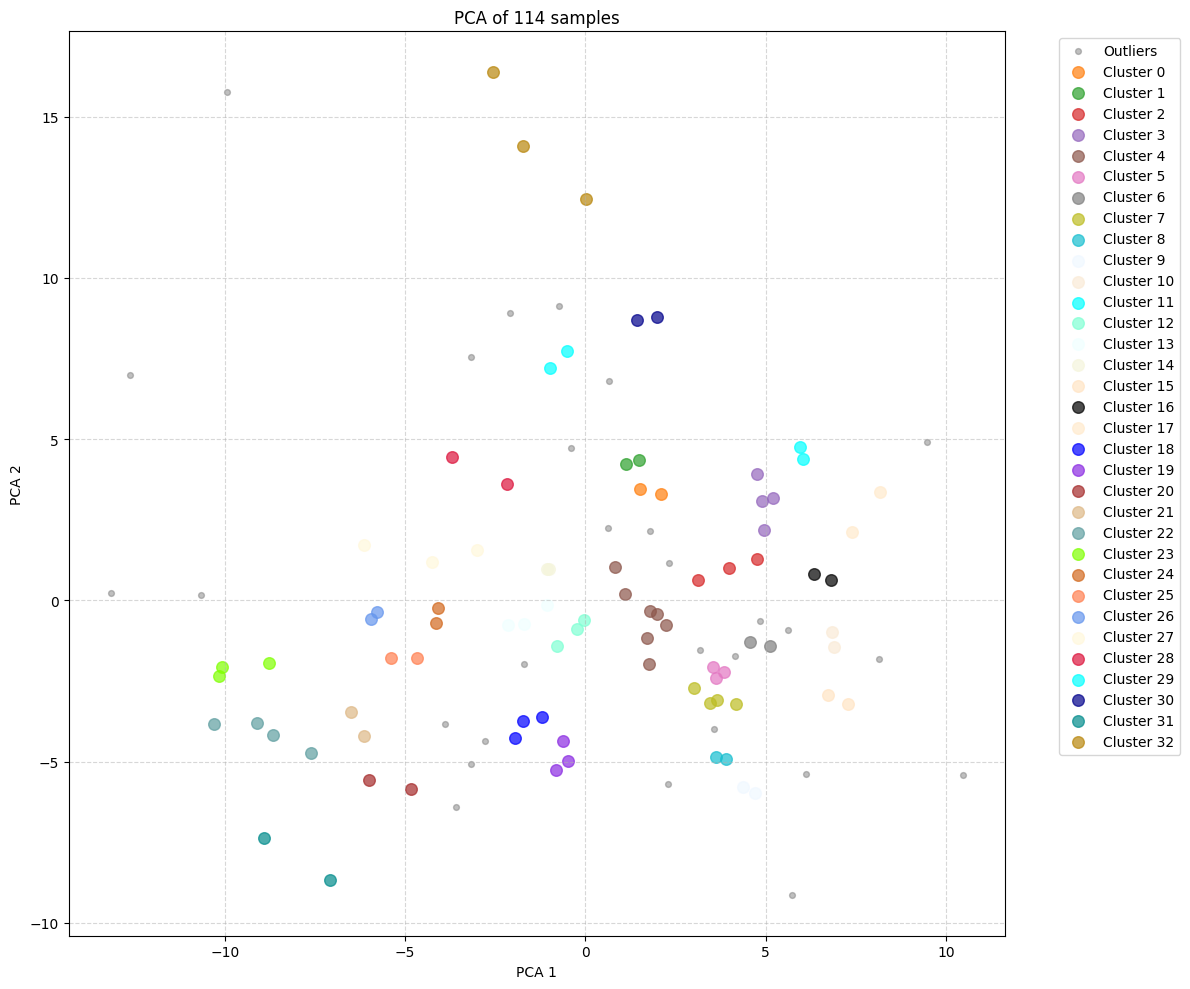

Best Silouhette Score :0.7662854194641113


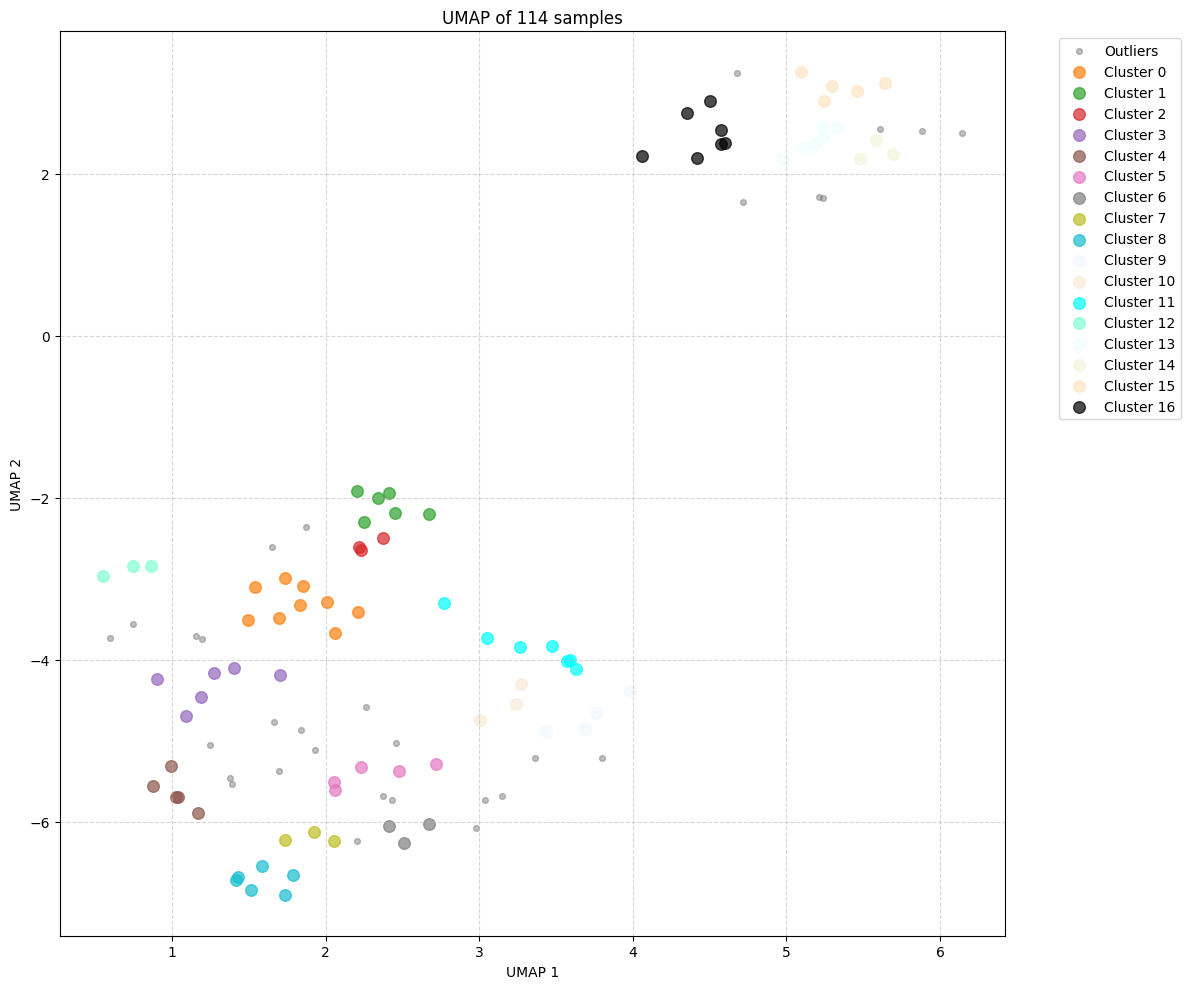

Accuracy: 0.5
ROC AUC: 0.4107142857142857
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.57      0.59        14
           1       0.33      0.38      0.35         8

    accuracy                           0.50        22
   macro avg       0.47      0.47      0.47        22
weighted avg       0.51      0.50      0.51        22

Mean ROC AUC (CV): 0.42857142857142855
Accuracy: 0.6363636363636364
ROC AUC: 0.5809523809523809
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73        15
           1       0.43      0.43      0.43         7

    accuracy                           0.64        22
   macro avg       0.58      0.58      0.58        22
weighted avg       0.64      0.64      0.64        22

Mean ROC AUC (CV): 0.5832352941176471
Accuracy: 0.5909090909090909
ROC AUC: 0.5128205128205128
Classification Report:
               precision    recall  f1-sco

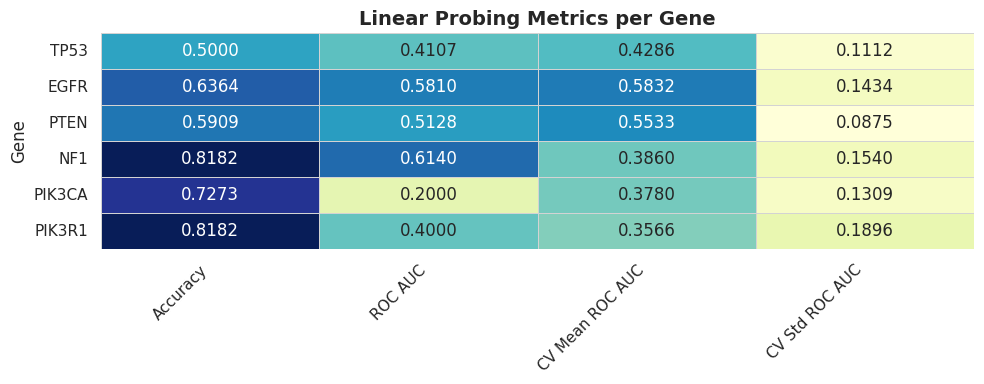

Mean Squared Error (MSE): 0.5849288008633626
Mean Absolute Error (MAE): 0.6554495200608274
RMSE Score: 0.764806381290953
Y_min: -0.7761717795112287, Y_max: 3.7406076994731627
Mean RMSE (CV): 0.9829129382198636
9th percentile -0.7761475580547708


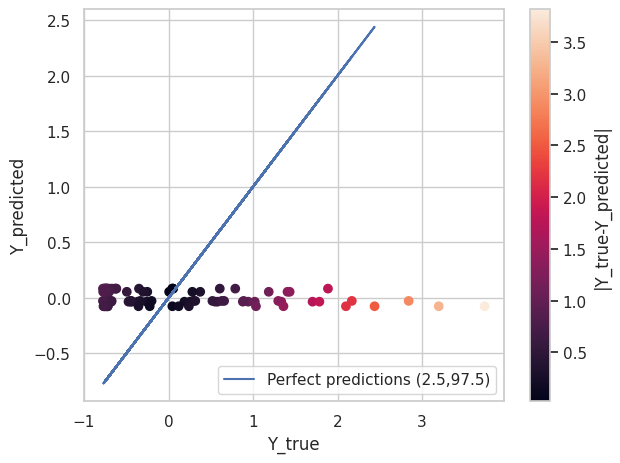

Mean Squared Error (MSE): 0.08579839529773702
Mean Absolute Error (MAE): 0.27290900039099864
RMSE Score: 0.2929136311231299
Y_min: -0.3017419966483975, Y_max: 7.281162278718516
Mean RMSE (CV): 0.765654424280652
9th percentile -0.30147383832265656


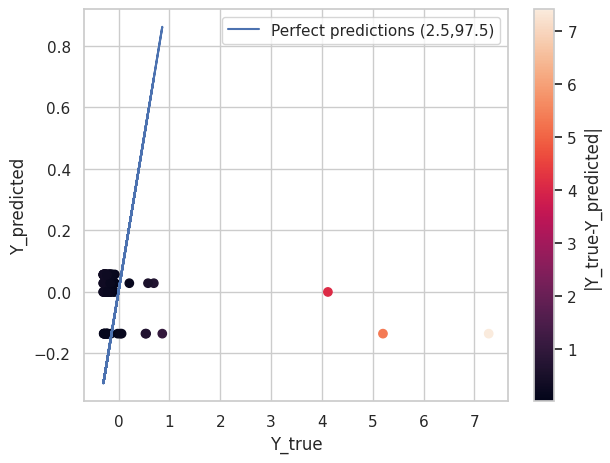

Mean Squared Error (MSE): 1.0311678906504749
Mean Absolute Error (MAE): 0.8430253300039371
RMSE Score: 1.015464371925709
Y_min: -2.0748497509996207, Y_max: 2.5085290479017854
Mean RMSE (CV): 1.0039706531414658
9th percentile -1.9468705923912122


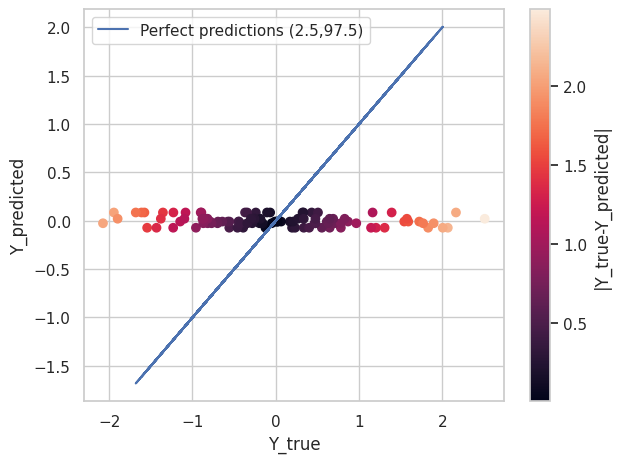

Mean Squared Error (MSE): 0.7655529310518899
Mean Absolute Error (MAE): 0.7547361745534579
RMSE Score: 0.8749588167747611
Y_min: -0.6148844930583284, Y_max: 2.7949966476216597
Mean RMSE (CV): 0.9982721734528794
9th percentile -0.6133712585363859


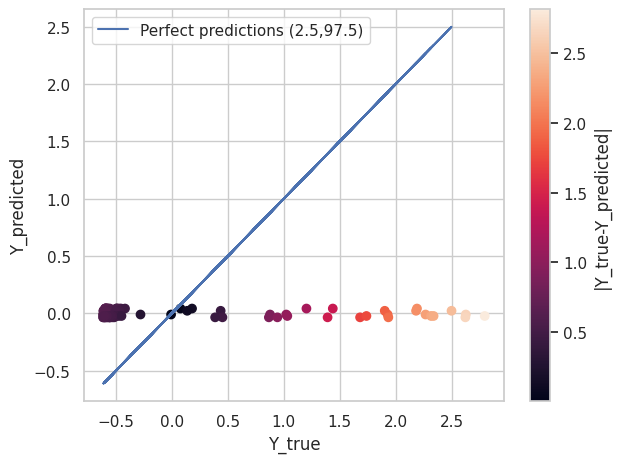

Mean Squared Error (MSE): 0.7772311718344819
Mean Absolute Error (MAE): 0.7018299225522849
RMSE Score: 0.8816071527809208
Y_min: -2.050127930977046, Y_max: 4.032821908282289
Mean RMSE (CV): 0.9806480268459492
9th percentile -1.785775640228863


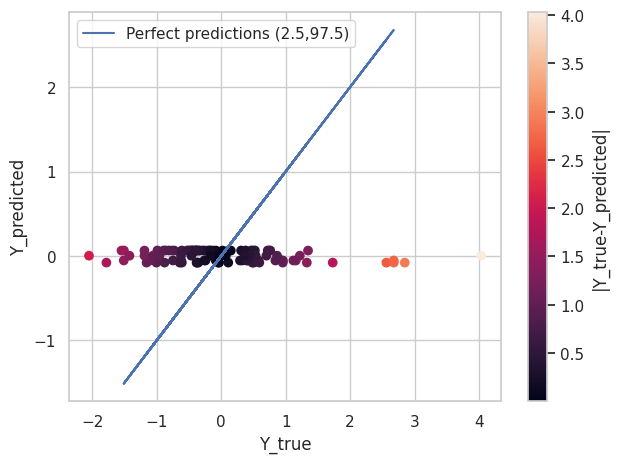

Mean Squared Error (MSE): 0.6920654505059426
Mean Absolute Error (MAE): 0.7312218906925478
RMSE Score: 0.831904712395562
Y_min: -1.3485242131873187, Y_max: 3.439450290420453
Mean RMSE (CV): 1.0110151412081028
9th percentile -1.3052585543893878


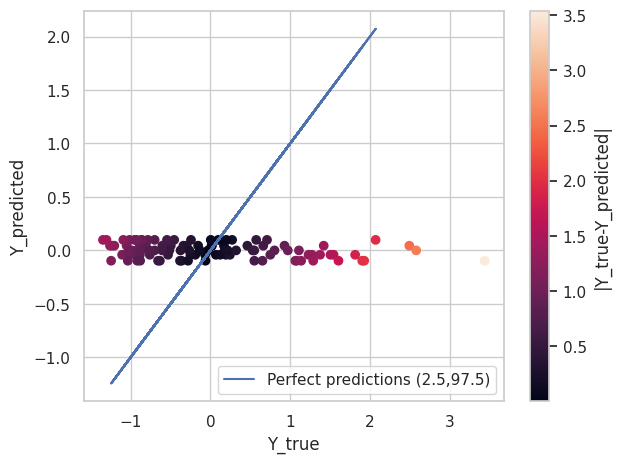

Mean Squared Error (MSE): 1.0094605330668212
Mean Absolute Error (MAE): 0.7017108639072889
RMSE Score: 1.004719131432671
Y_min: -0.9438632436261545, Y_max: 4.155649606554423
Mean RMSE (CV): 0.9826486123770011
9th percentile -0.9438632436261545


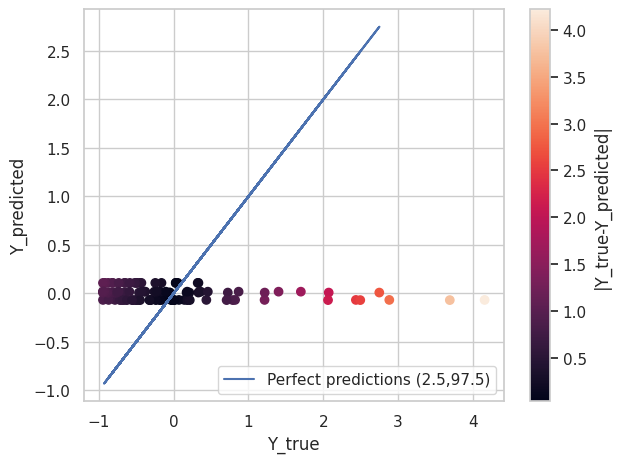

Mean Squared Error (MSE): 0.15258193526217992
Mean Absolute Error (MAE): 0.34966730310522204
RMSE Score: 0.3906173770612105
Y_min: -0.3437568256133891, Y_max: 6.619521078607543
Mean RMSE (CV): 0.8708284267687437
9th percentile -0.3296203036934892


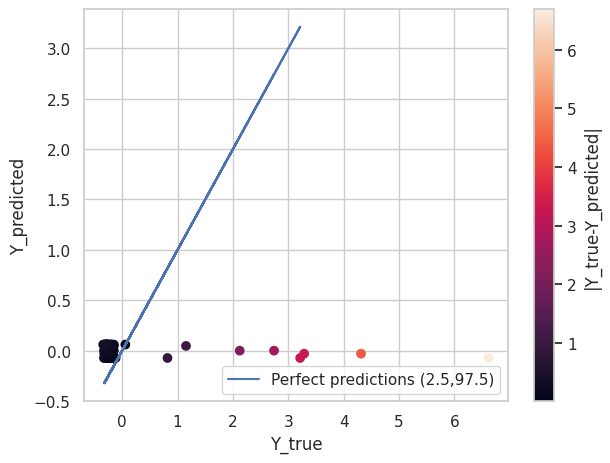

Mean Squared Error (MSE): 0.4164746046673043
Mean Absolute Error (MAE): 0.5925833602049839
RMSE Score: 0.6453484366350509
Y_min: -0.8546475030574292, Y_max: 6.352482935852151
Mean RMSE (CV): 0.9569836536651364
9th percentile -0.8515743231820007


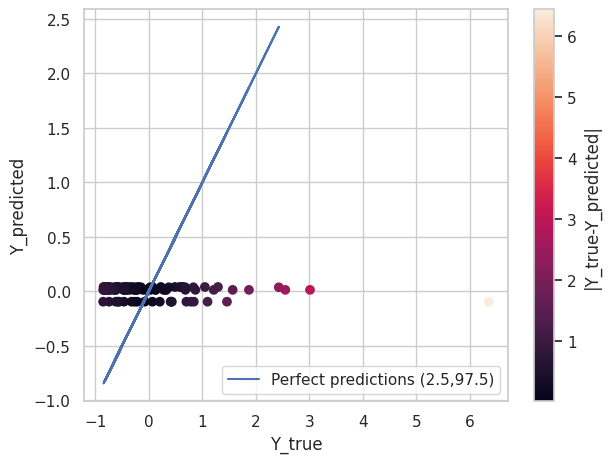

Mean Squared Error (MSE): 1.8676571227427325
Mean Absolute Error (MAE): 0.911973417191684
RMSE Score: 1.366622523867777
Y_min: -1.0406770201116537, Y_max: 5.204775754553968
Mean RMSE (CV): 0.9816083047052127
9th percentile -1.0375753757661121


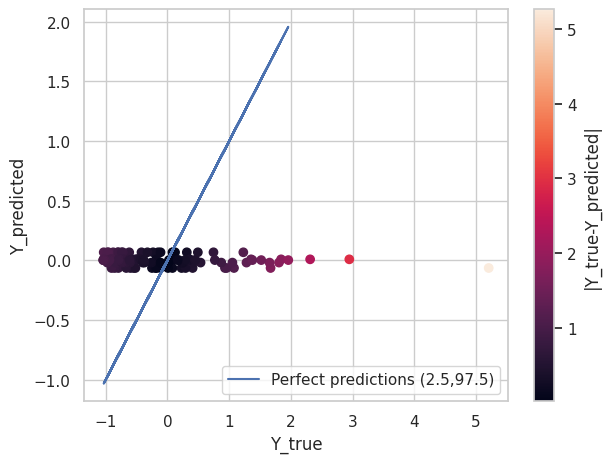

Mean Squared Error (MSE): 1.1913532341646884
Mean Absolute Error (MAE): 0.770155153202109
RMSE Score: 1.0914912890924455
Y_min: -1.6491985515099434, Y_max: 4.3719944781247335
Mean RMSE (CV): 0.9597806266348534
9th percentile -1.6428461610821528


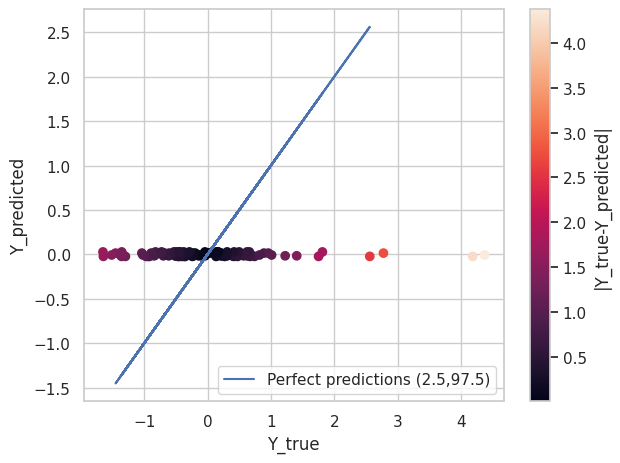

Mean Squared Error (MSE): 0.5637386395109937
Mean Absolute Error (MAE): 0.578558567569321
RMSE Score: 0.7508253055877869
Y_min: -1.1489154688789, Y_max: 3.7554242093284333
Mean RMSE (CV): 0.9727794554571674
9th percentile -1.1468838665895458


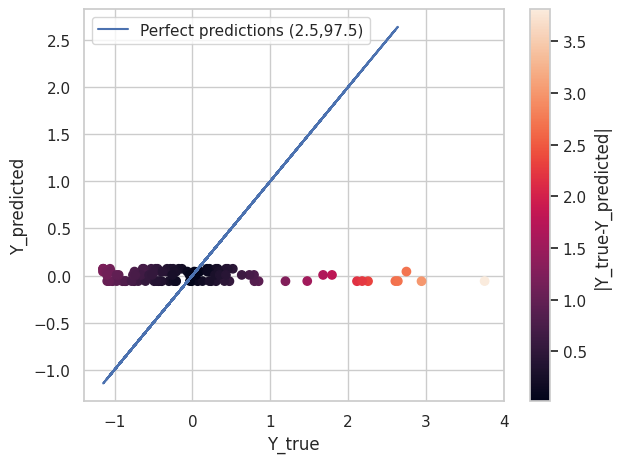

Mean Squared Error (MSE): 0.7391311692959457
Mean Absolute Error (MAE): 0.7153921240605595
RMSE Score: 0.8597273807992541
Y_min: -1.4088430206480322, Y_max: 3.640884875730961
Mean RMSE (CV): 0.9874270010307681
9th percentile -1.3935864958347566


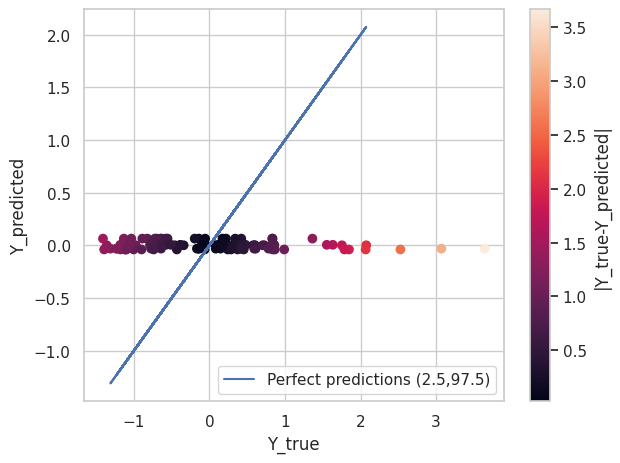

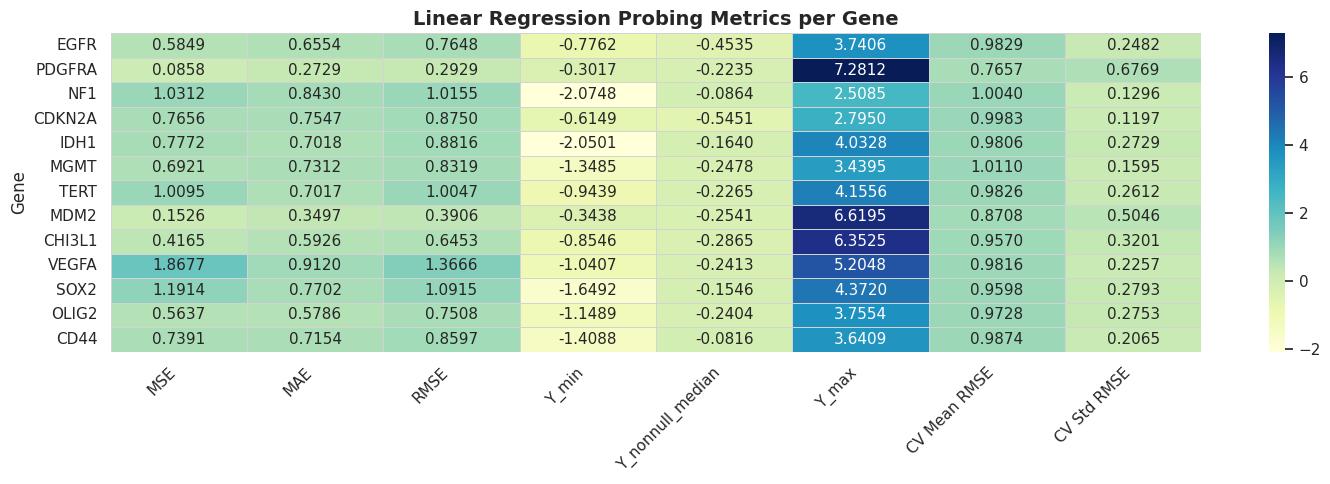

{'lp_wes':      Gene  Accuracy  ROC AUC  CV Mean ROC AUC  CV Std ROC AUC
 0    TP53    0.5000   0.4107           0.4286          0.1112
 1    EGFR    0.6364   0.5810           0.5832          0.1434
 2    PTEN    0.5909   0.5128           0.5533          0.0875
 3     NF1    0.8182   0.6140           0.3860          0.1540
 4  PIK3CA    0.7273   0.2000           0.3780          0.1309
 5  PIK3R1    0.8182   0.4000           0.3566          0.1896,
 'lp_bulk':       Gene     MSE     MAE    RMSE   Y_min  Y_nonnull_median   Y_max  \
 0     EGFR  0.5849  0.6554  0.7648 -0.7762           -0.4535  3.7406   
 1   PDGFRA  0.0858  0.2729  0.2929 -0.3017           -0.2235  7.2812   
 2      NF1  1.0312  0.8430  1.0155 -2.0748           -0.0864  2.5085   
 3   CDKN2A  0.7656  0.7547  0.8750 -0.6149           -0.5451  2.7950   
 4     IDH1  0.7772  0.7018  0.8816 -2.0501           -0.1640  4.0328   
 5     MGMT  0.6921  0.7312  0.8319 -1.3485           -0.2478  3.4395   
 6     TERT  1.0095  0.701

In [30]:
analyze_embeddings(snvs_indels, bRNA_TPM, batch_all, "old_joined", "./old_joined/", batch = clm_outputs[1])

### old_joined_with_refinement

In [31]:
jm = load_model(JoinedModule, 
                 "/home/sagemaker-user/gbm_hackathon/saved_models/old_joined_with_refinement.ckpt",
                "/home/sagemaker-user/gbm_hackathon/saved_models/cfg_old_joined_with_refinement.ckpt",
                device= "cpu")
constrative_outputs = jm.mme(X_dict)
tensor = concat_modality_embeddings(constrative_outputs)
clm_outputs = jm.clm.refinement_block(constrative_outputs, avail_mods)

{'net_type': 'mlp', 'device': device(type='cpu'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found

Model succesfully loaded on

In [32]:
clm_outputs.shape

torch.Size([114, 192])

Best Silouhette Score :0.3477984666824341


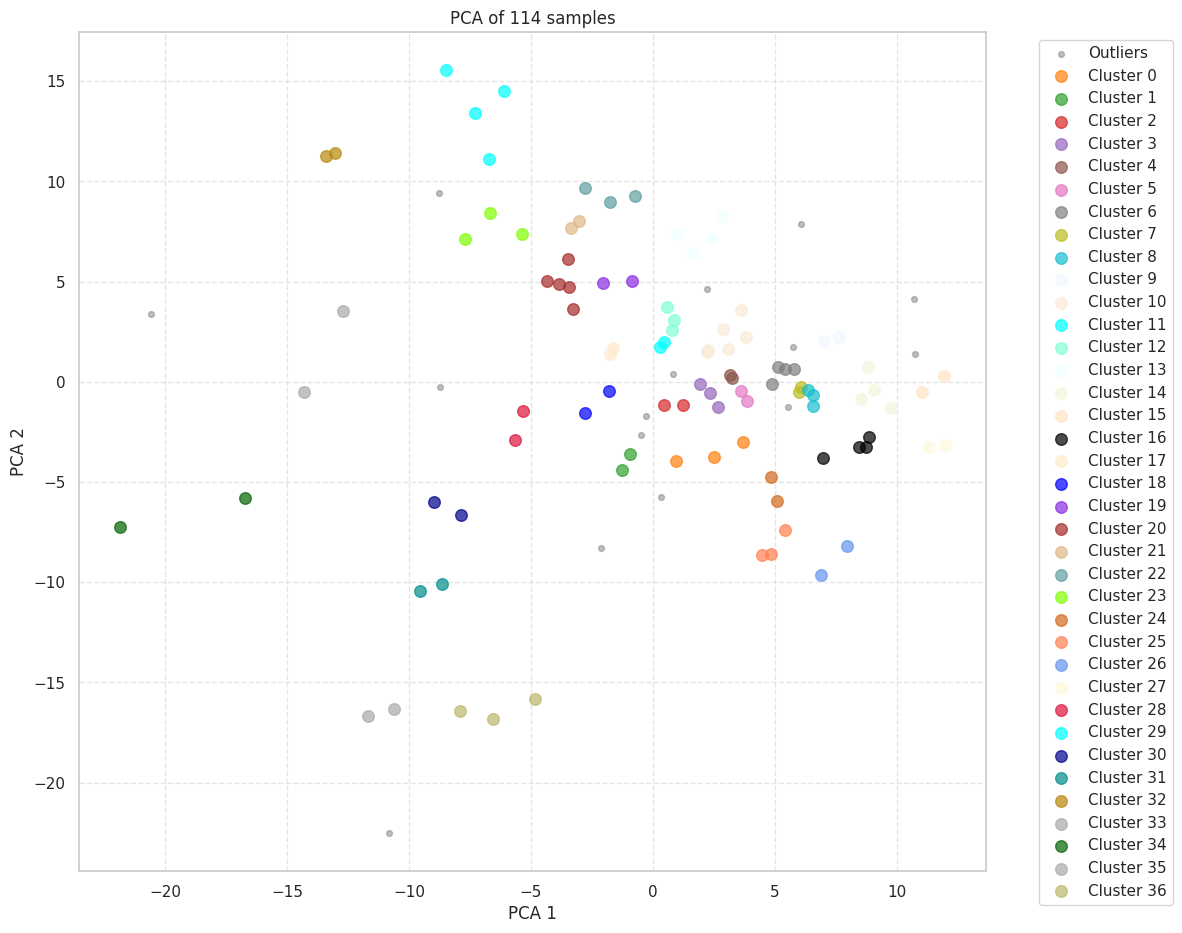

Best Silouhette Score :0.34011968970298767


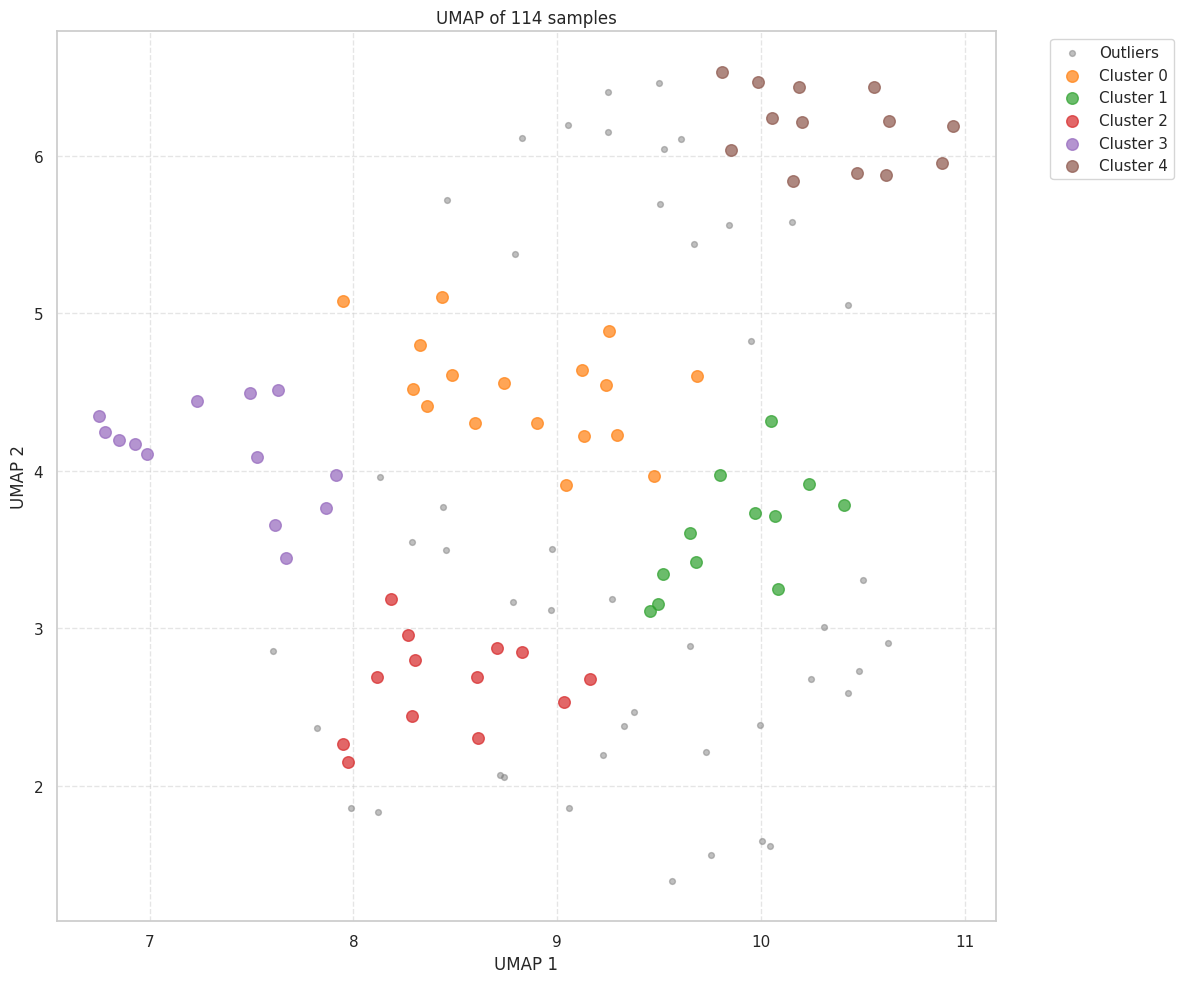

Accuracy: 0.45454545454545453
ROC AUC: 0.5267857142857143
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.50      0.54        14
           1       0.30      0.38      0.33         8

    accuracy                           0.45        22
   macro avg       0.44      0.44      0.44        22
weighted avg       0.48      0.45      0.46        22

Mean ROC AUC (CV): 0.6048979591836734
Accuracy: 0.5
ROC AUC: 0.5047619047619047
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.67      0.65        15
           1       0.17      0.14      0.15         7

    accuracy                           0.50        22
   macro avg       0.40      0.40      0.40        22
weighted avg       0.48      0.50      0.49        22

Mean ROC AUC (CV): 0.7170588235294119
Accuracy: 0.5909090909090909
ROC AUC: 0.6666666666666666
Classification Report:
               precision    recall  f1-sco

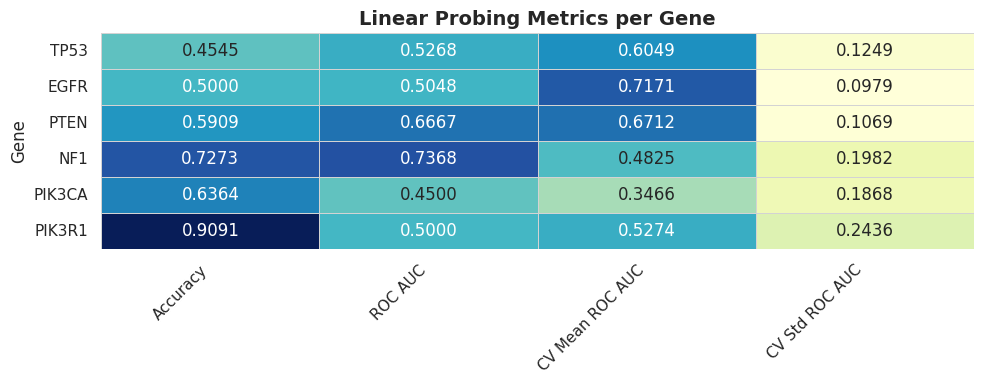

Mean Squared Error (MSE): 0.5849288008633626
Mean Absolute Error (MAE): 0.6554495200608274
RMSE Score: 0.764806381290953
Y_min: -0.7761717795112287, Y_max: 3.7406076994731627
Mean RMSE (CV): 0.9829129382198636
9th percentile -0.7761475580547708


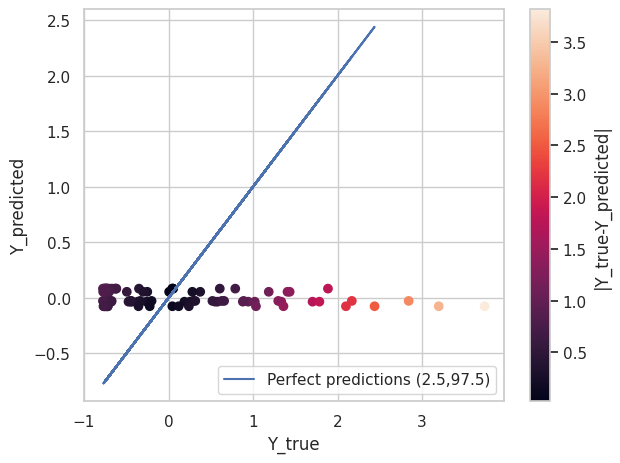

Mean Squared Error (MSE): 0.08579839529773702
Mean Absolute Error (MAE): 0.27290900039099864
RMSE Score: 0.2929136311231299
Y_min: -0.3017419966483975, Y_max: 7.281162278718516
Mean RMSE (CV): 0.765654424280652
9th percentile -0.30147383832265656


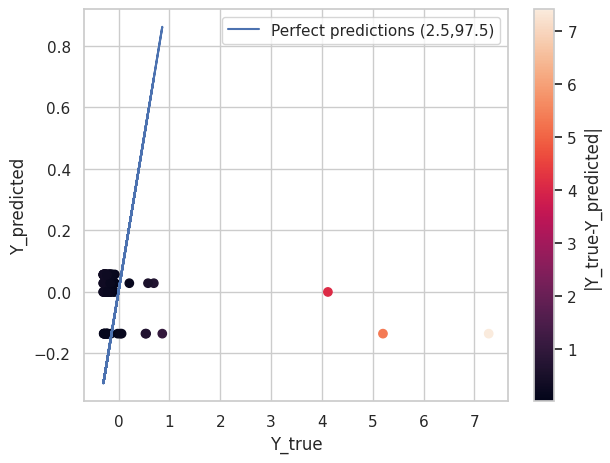

Mean Squared Error (MSE): 1.0311678906504749
Mean Absolute Error (MAE): 0.8430253300039371
RMSE Score: 1.015464371925709
Y_min: -2.0748497509996207, Y_max: 2.5085290479017854
Mean RMSE (CV): 1.0039706531414658
9th percentile -1.9468705923912122


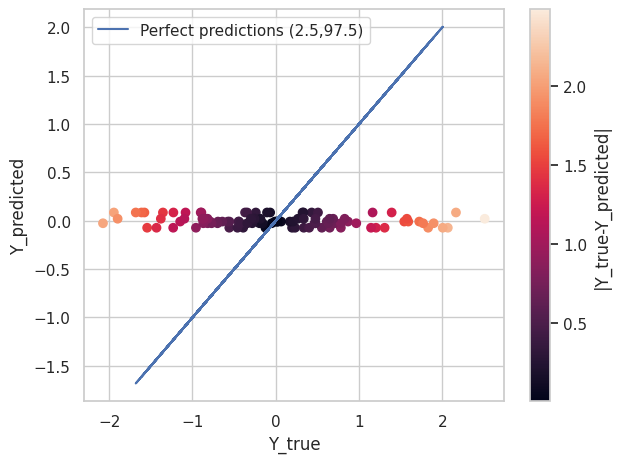

Mean Squared Error (MSE): 0.7655529310518899
Mean Absolute Error (MAE): 0.7547361745534579
RMSE Score: 0.8749588167747611
Y_min: -0.6148844930583284, Y_max: 2.7949966476216597
Mean RMSE (CV): 0.9982721734528794
9th percentile -0.6133712585363859


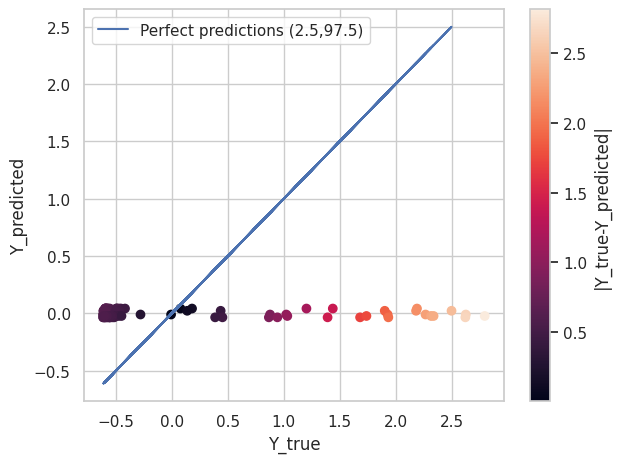

Mean Squared Error (MSE): 0.7772311718344819
Mean Absolute Error (MAE): 0.7018299225522849
RMSE Score: 0.8816071527809208
Y_min: -2.050127930977046, Y_max: 4.032821908282289
Mean RMSE (CV): 0.9806480268459492
9th percentile -1.785775640228863


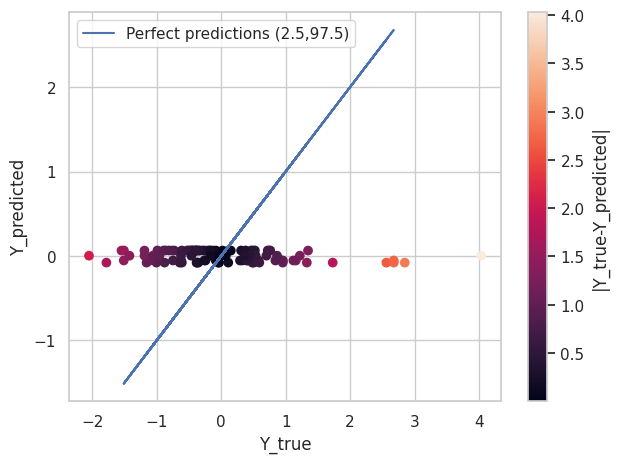

Mean Squared Error (MSE): 0.6920654505059426
Mean Absolute Error (MAE): 0.7312218906925478
RMSE Score: 0.831904712395562
Y_min: -1.3485242131873187, Y_max: 3.439450290420453
Mean RMSE (CV): 1.0110151412081028
9th percentile -1.3052585543893878


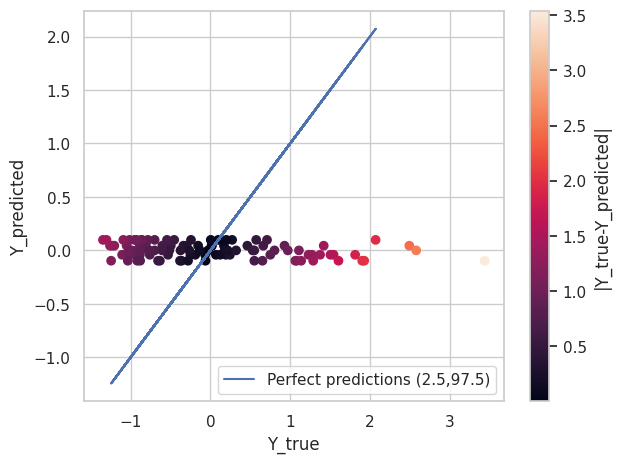

Mean Squared Error (MSE): 1.0094605330668212
Mean Absolute Error (MAE): 0.7017108639072889
RMSE Score: 1.004719131432671
Y_min: -0.9438632436261545, Y_max: 4.155649606554423
Mean RMSE (CV): 0.9826486123770011
9th percentile -0.9438632436261545


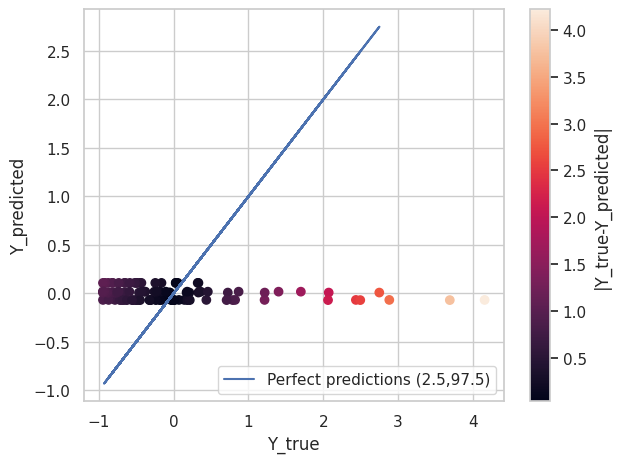

Mean Squared Error (MSE): 0.15258193526217992
Mean Absolute Error (MAE): 0.34966730310522204
RMSE Score: 0.3906173770612105
Y_min: -0.3437568256133891, Y_max: 6.619521078607543
Mean RMSE (CV): 0.8708284267687437
9th percentile -0.3296203036934892


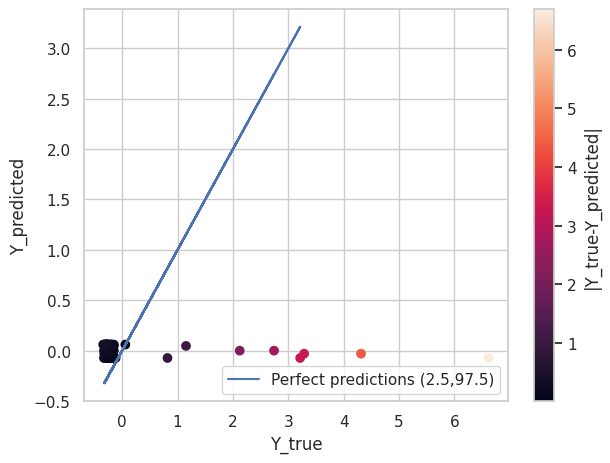

Mean Squared Error (MSE): 0.4164746046673043
Mean Absolute Error (MAE): 0.5925833602049839
RMSE Score: 0.6453484366350509
Y_min: -0.8546475030574292, Y_max: 6.352482935852151
Mean RMSE (CV): 0.9569836536651364
9th percentile -0.8515743231820007


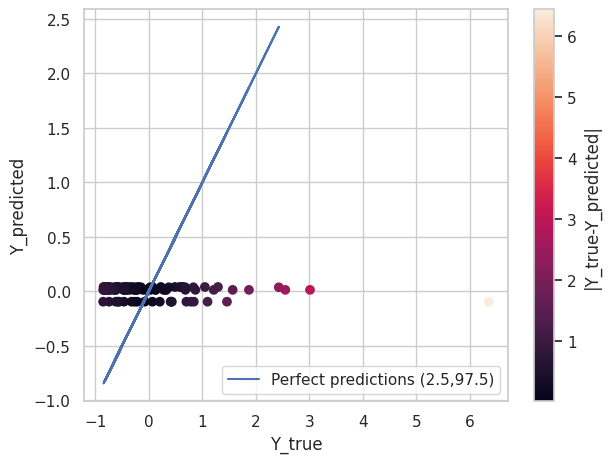

Mean Squared Error (MSE): 1.8676571227427325
Mean Absolute Error (MAE): 0.911973417191684
RMSE Score: 1.366622523867777
Y_min: -1.0406770201116537, Y_max: 5.204775754553968
Mean RMSE (CV): 0.9816083047052127
9th percentile -1.0375753757661121


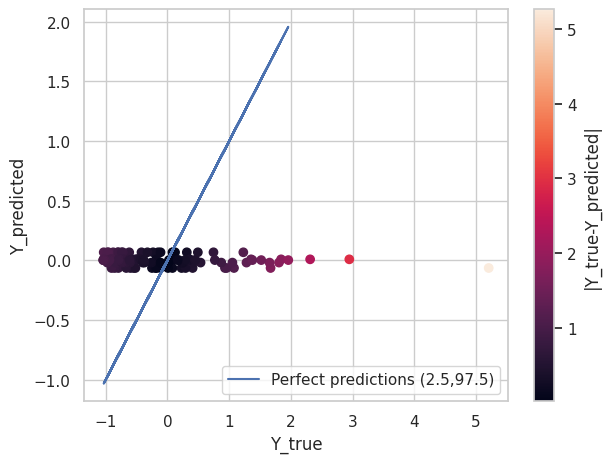

Mean Squared Error (MSE): 1.1913532341646884
Mean Absolute Error (MAE): 0.770155153202109
RMSE Score: 1.0914912890924455
Y_min: -1.6491985515099434, Y_max: 4.3719944781247335
Mean RMSE (CV): 0.9597806266348534
9th percentile -1.6428461610821528


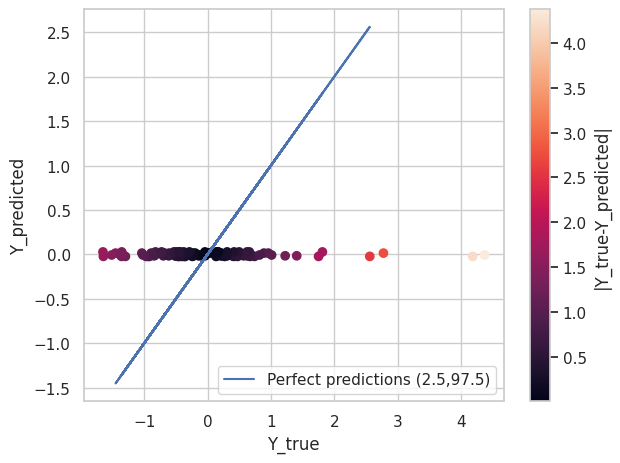

Mean Squared Error (MSE): 0.5637386395109937
Mean Absolute Error (MAE): 0.578558567569321
RMSE Score: 0.7508253055877869
Y_min: -1.1489154688789, Y_max: 3.7554242093284333
Mean RMSE (CV): 0.9727794554571674
9th percentile -1.1468838665895458


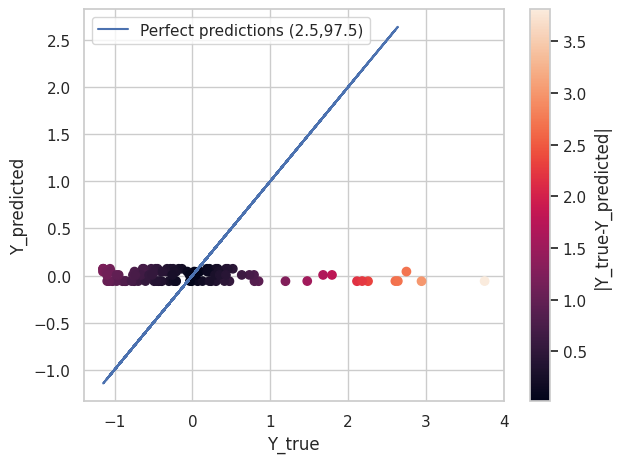

Mean Squared Error (MSE): 0.7391311692959457
Mean Absolute Error (MAE): 0.7153921240605595
RMSE Score: 0.8597273807992541
Y_min: -1.4088430206480322, Y_max: 3.640884875730961
Mean RMSE (CV): 0.9874270010307681
9th percentile -1.3935864958347566


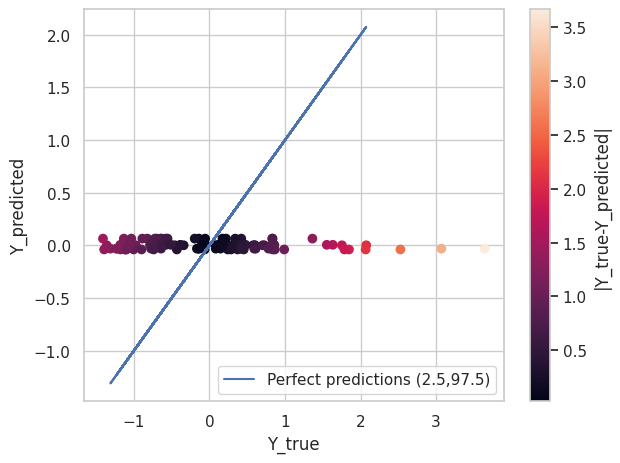

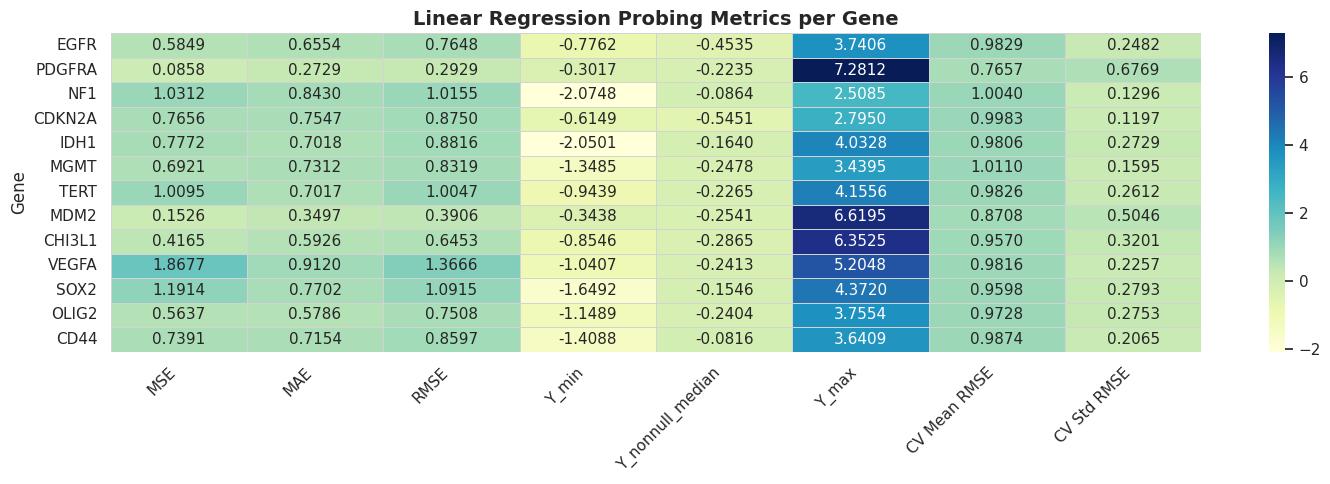

{'lp_wes':      Gene  Accuracy  ROC AUC  CV Mean ROC AUC  CV Std ROC AUC
 0    TP53    0.4545   0.5268           0.6049          0.1249
 1    EGFR    0.5000   0.5048           0.7171          0.0979
 2    PTEN    0.5909   0.6667           0.6712          0.1069
 3     NF1    0.7273   0.7368           0.4825          0.1982
 4  PIK3CA    0.6364   0.4500           0.3466          0.1868
 5  PIK3R1    0.9091   0.5000           0.5274          0.2436,
 'lp_bulk':       Gene     MSE     MAE    RMSE   Y_min  Y_nonnull_median   Y_max  \
 0     EGFR  0.5849  0.6554  0.7648 -0.7762           -0.4535  3.7406   
 1   PDGFRA  0.0858  0.2729  0.2929 -0.3017           -0.2235  7.2812   
 2      NF1  1.0312  0.8430  1.0155 -2.0748           -0.0864  2.5085   
 3   CDKN2A  0.7656  0.7547  0.8750 -0.6149           -0.5451  2.7950   
 4     IDH1  0.7772  0.7018  0.8816 -2.0501           -0.1640  4.0328   
 5     MGMT  0.6921  0.7312  0.8319 -1.3485           -0.2478  3.4395   
 6     TERT  1.0095  0.701

In [33]:
analyze_embeddings(snvs_indels, bRNA_TPM, batch_all, "old_joined_with_refinement", "./old_joined_with_refinement/", batch = clm_outputs)

### New_joined_no_refinement

In [34]:
jm = load_model(JoinedModule, 
                 "/home/sagemaker-user/gbm_hackathon/saved_models/new_joined_no_refinement.ckpt",
                "/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_joined_no_refinement.ckpt",
                device= "cpu")
constrative_outputs = jm.mme(X_dict)
tensor = concat_modality_embeddings(constrative_outputs)
clm_outputs = jm.clm(constrative_outputs, avail_mods)

{'net_type': 'mlp', 'device': device(type='cpu'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found

Model succesfully loaded on device cpu. Model

Best Silouhette Score :0.351127564907074


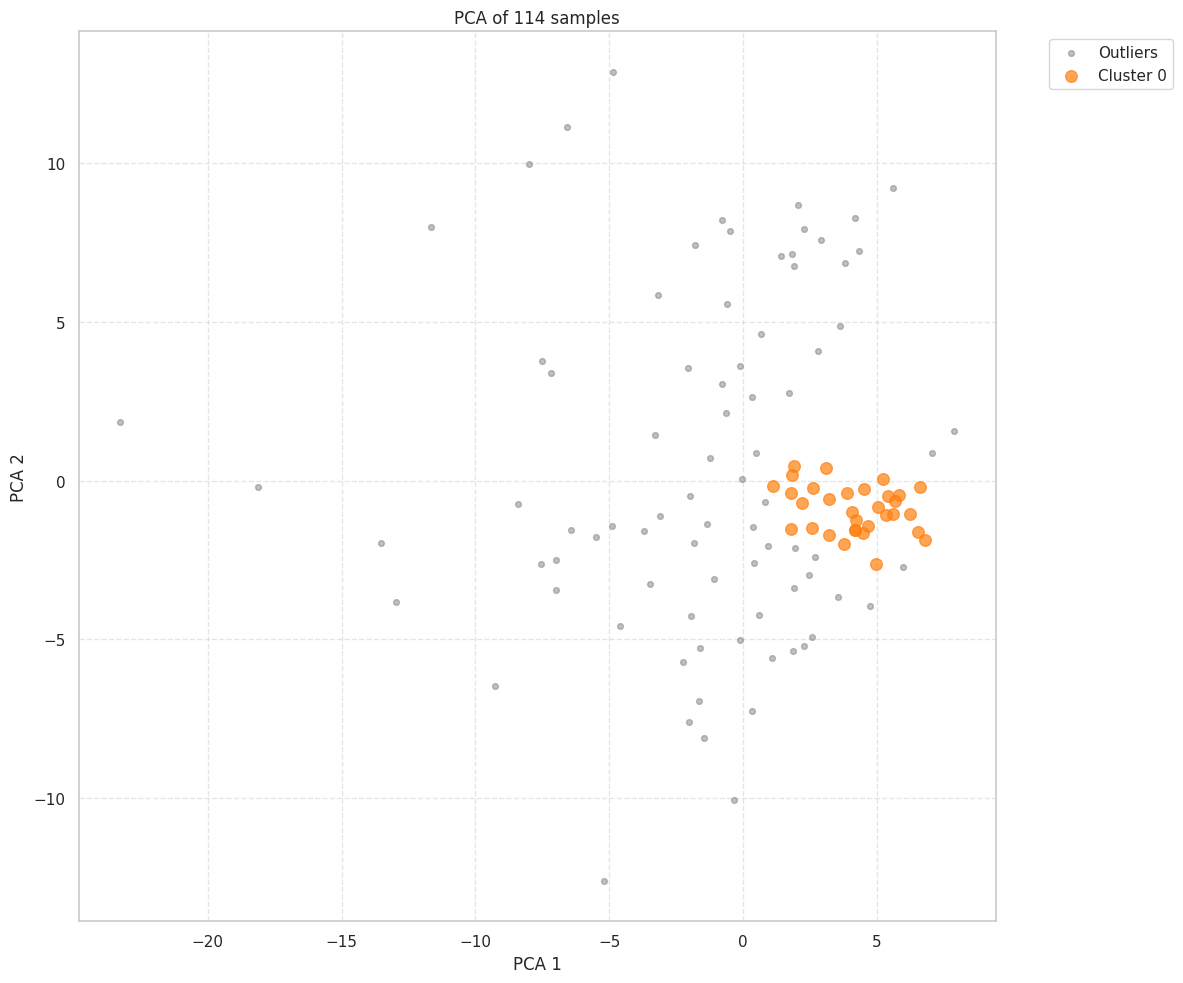

Best Silouhette Score :0.362210214138031


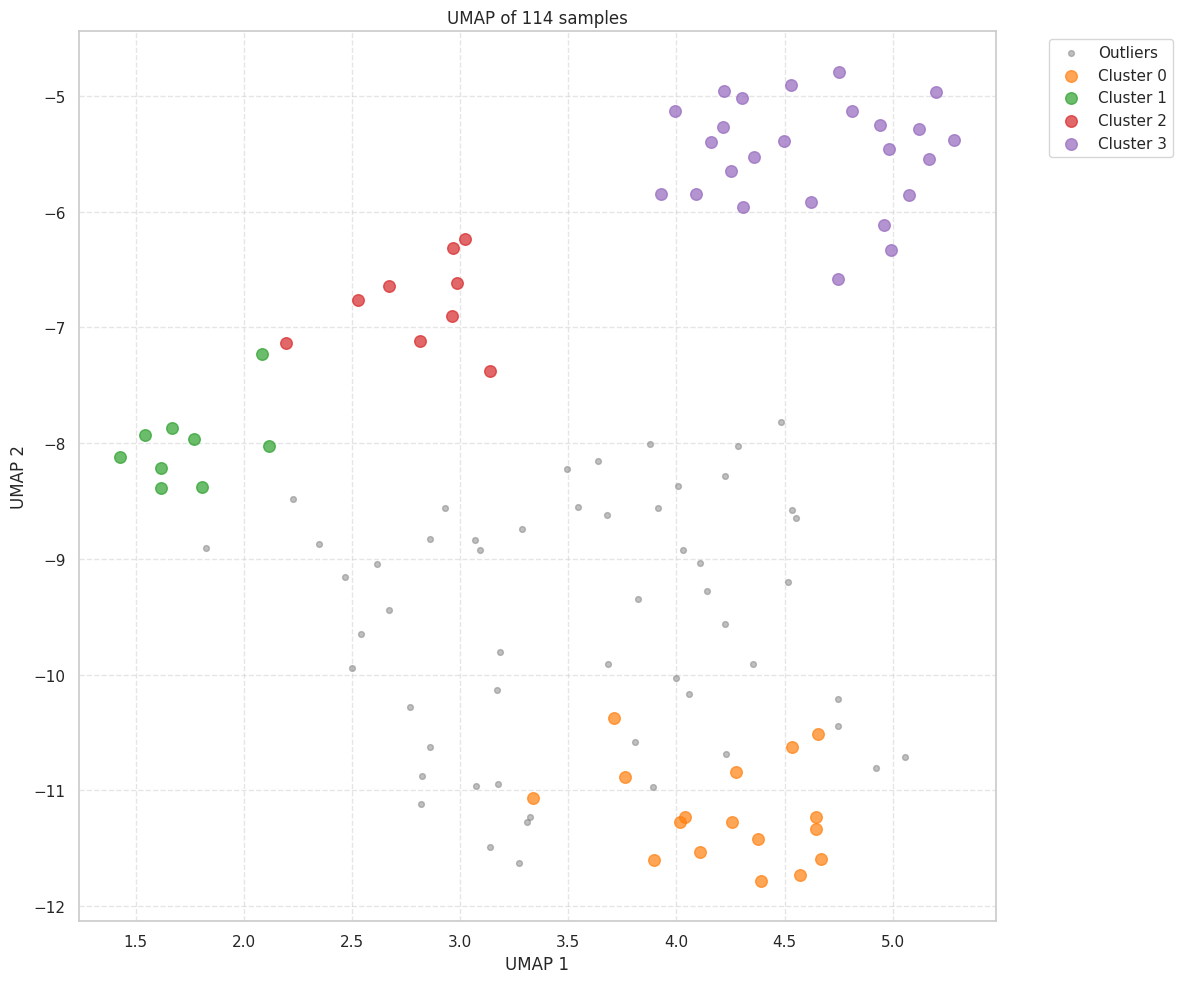

Accuracy: 0.36363636363636365
ROC AUC: 0.39285714285714285
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50        14
           1       0.12      0.12      0.12         8

    accuracy                           0.36        22
   macro avg       0.31      0.31      0.31        22
weighted avg       0.36      0.36      0.36        22

Mean ROC AUC (CV): 0.6409523809523809
Accuracy: 0.6363636363636364
ROC AUC: 0.6666666666666666
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73        15
           1       0.43      0.43      0.43         7

    accuracy                           0.64        22
   macro avg       0.58      0.58      0.58        22
weighted avg       0.64      0.64      0.64        22

Mean ROC AUC (CV): 0.6995588235294118
Accuracy: 0.5454545454545454
ROC AUC: 0.5470085470085471
Classification Report:
               precision  

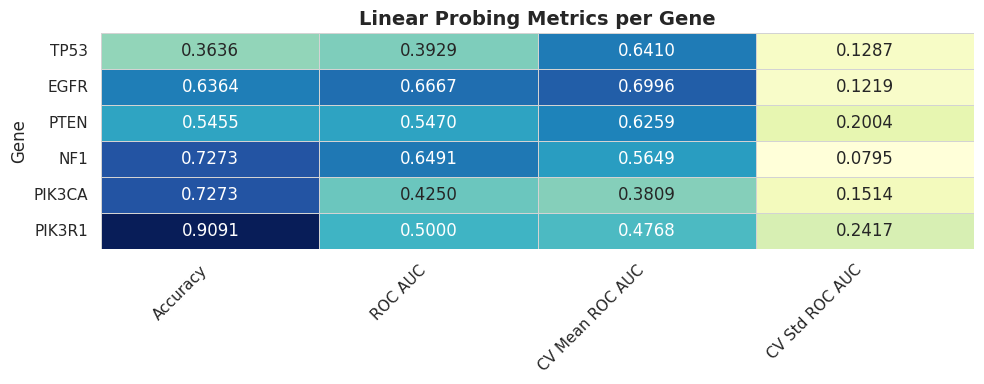

Mean Squared Error (MSE): 0.5849288008633626
Mean Absolute Error (MAE): 0.6554495200608274
RMSE Score: 0.764806381290953
Y_min: -0.7761717795112287, Y_max: 3.7406076994731627
Mean RMSE (CV): 0.9829129382198636
9th percentile -0.7761475580547708


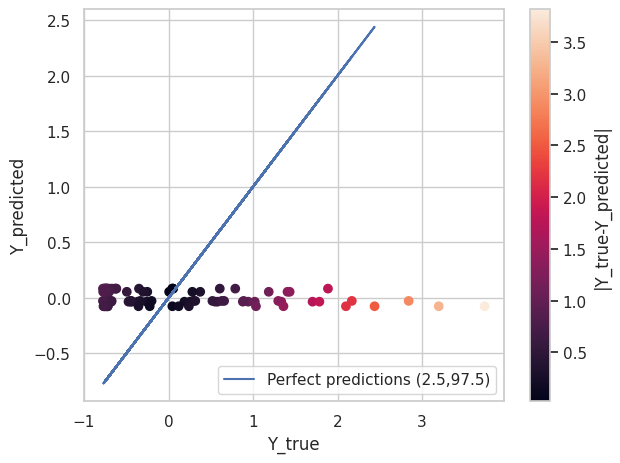

Mean Squared Error (MSE): 0.08579839529773702
Mean Absolute Error (MAE): 0.27290900039099864
RMSE Score: 0.2929136311231299
Y_min: -0.3017419966483975, Y_max: 7.281162278718516
Mean RMSE (CV): 0.765654424280652
9th percentile -0.30147383832265656


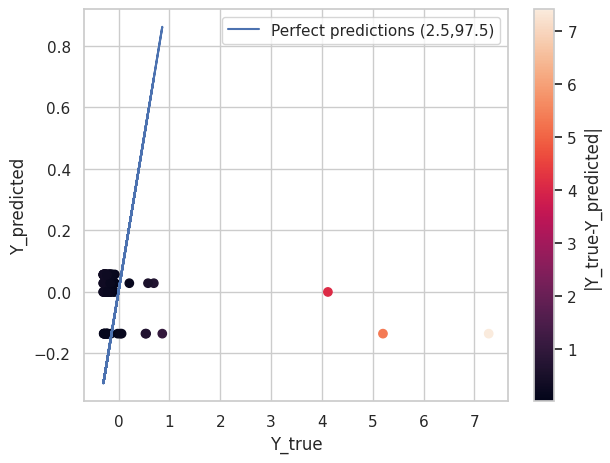

Mean Squared Error (MSE): 1.0311678906504749
Mean Absolute Error (MAE): 0.8430253300039371
RMSE Score: 1.015464371925709
Y_min: -2.0748497509996207, Y_max: 2.5085290479017854
Mean RMSE (CV): 1.0039706531414658
9th percentile -1.9468705923912122


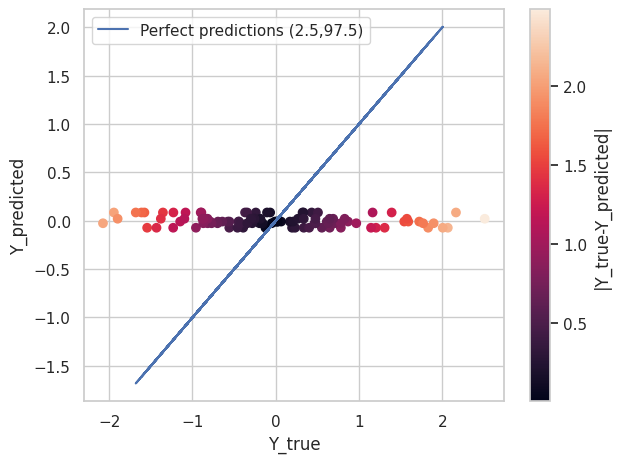

Mean Squared Error (MSE): 0.7655529310518899
Mean Absolute Error (MAE): 0.7547361745534579
RMSE Score: 0.8749588167747611
Y_min: -0.6148844930583284, Y_max: 2.7949966476216597
Mean RMSE (CV): 0.9982721734528794
9th percentile -0.6133712585363859


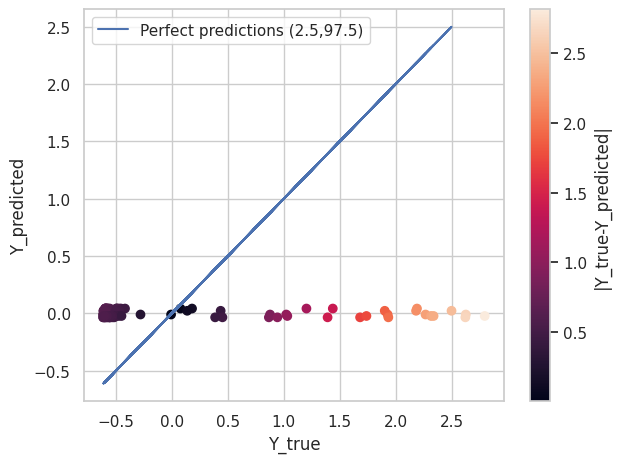

Mean Squared Error (MSE): 0.7772311718344819
Mean Absolute Error (MAE): 0.7018299225522849
RMSE Score: 0.8816071527809208
Y_min: -2.050127930977046, Y_max: 4.032821908282289
Mean RMSE (CV): 0.9806480268459492
9th percentile -1.785775640228863


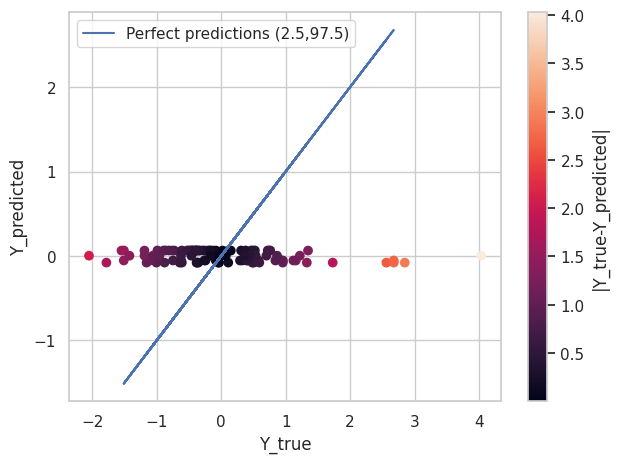

Mean Squared Error (MSE): 0.6920654505059426
Mean Absolute Error (MAE): 0.7312218906925478
RMSE Score: 0.831904712395562
Y_min: -1.3485242131873187, Y_max: 3.439450290420453
Mean RMSE (CV): 1.0110151412081028
9th percentile -1.3052585543893878


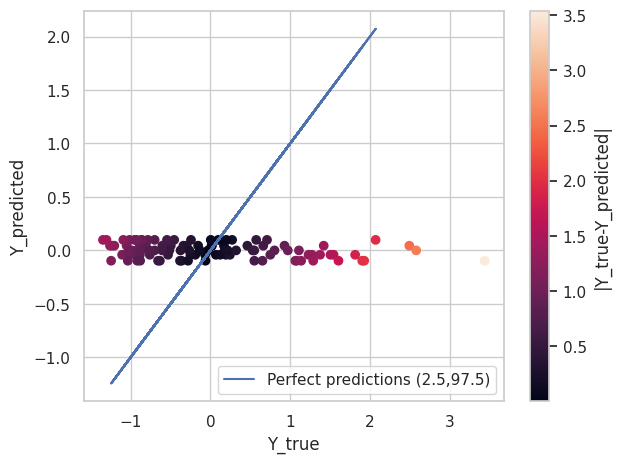

Mean Squared Error (MSE): 1.0094605330668212
Mean Absolute Error (MAE): 0.7017108639072889
RMSE Score: 1.004719131432671
Y_min: -0.9438632436261545, Y_max: 4.155649606554423
Mean RMSE (CV): 0.9826486123770011
9th percentile -0.9438632436261545


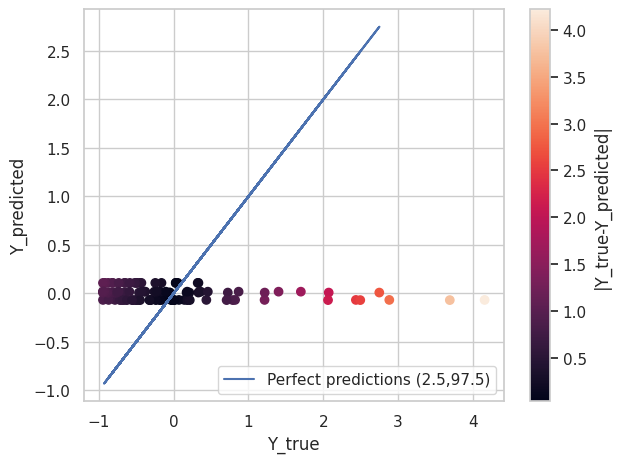

Mean Squared Error (MSE): 0.15258193526217992
Mean Absolute Error (MAE): 0.34966730310522204
RMSE Score: 0.3906173770612105
Y_min: -0.3437568256133891, Y_max: 6.619521078607543
Mean RMSE (CV): 0.8708284267687437
9th percentile -0.3296203036934892


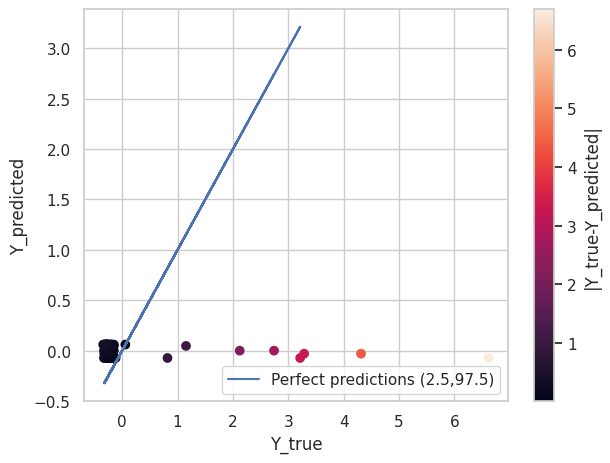

Mean Squared Error (MSE): 0.4164746046673043
Mean Absolute Error (MAE): 0.5925833602049839
RMSE Score: 0.6453484366350509
Y_min: -0.8546475030574292, Y_max: 6.352482935852151
Mean RMSE (CV): 0.9569836536651364
9th percentile -0.8515743231820007


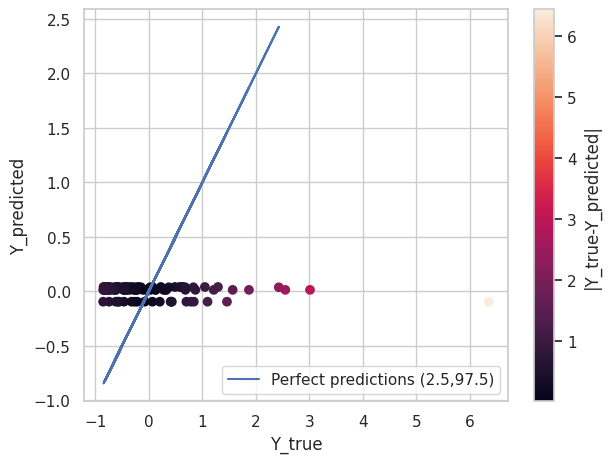

Mean Squared Error (MSE): 1.8676571227427325
Mean Absolute Error (MAE): 0.911973417191684
RMSE Score: 1.366622523867777
Y_min: -1.0406770201116537, Y_max: 5.204775754553968
Mean RMSE (CV): 0.9816083047052127
9th percentile -1.0375753757661121


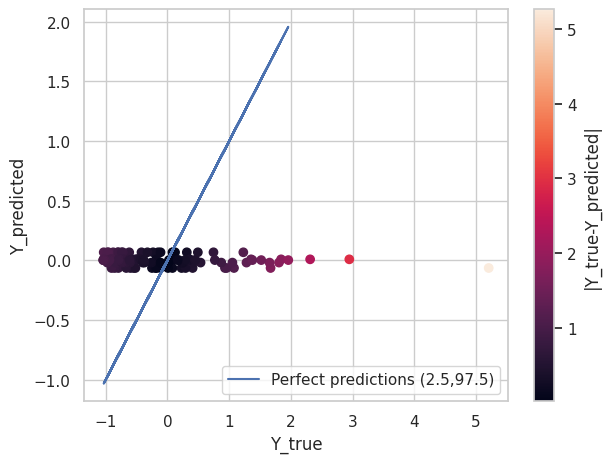

Mean Squared Error (MSE): 1.1913532341646884
Mean Absolute Error (MAE): 0.770155153202109
RMSE Score: 1.0914912890924455
Y_min: -1.6491985515099434, Y_max: 4.3719944781247335
Mean RMSE (CV): 0.9597806266348534
9th percentile -1.6428461610821528


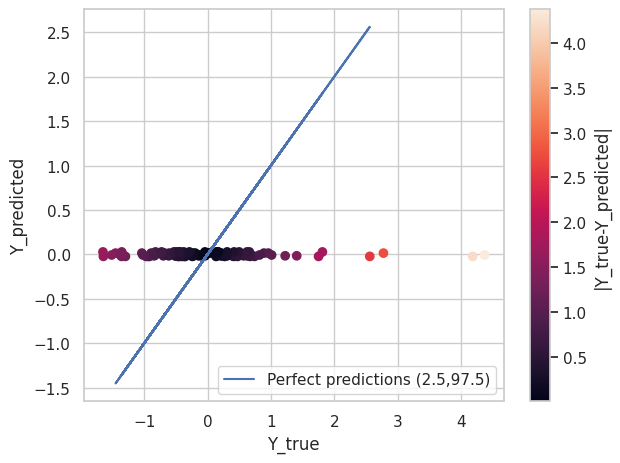

Mean Squared Error (MSE): 0.5637386395109937
Mean Absolute Error (MAE): 0.578558567569321
RMSE Score: 0.7508253055877869
Y_min: -1.1489154688789, Y_max: 3.7554242093284333
Mean RMSE (CV): 0.9727794554571674
9th percentile -1.1468838665895458


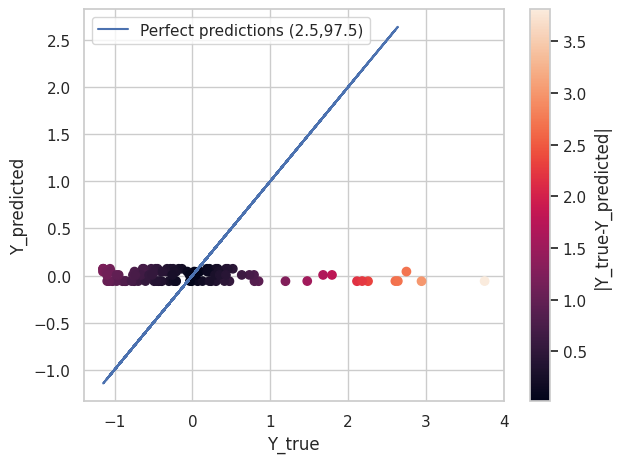

Mean Squared Error (MSE): 0.7391311692959457
Mean Absolute Error (MAE): 0.7153921240605595
RMSE Score: 0.8597273807992541
Y_min: -1.4088430206480322, Y_max: 3.640884875730961
Mean RMSE (CV): 0.9874270010307681
9th percentile -1.3935864958347566


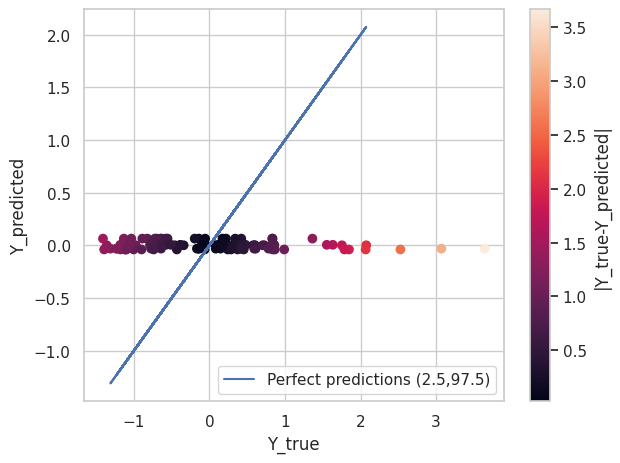

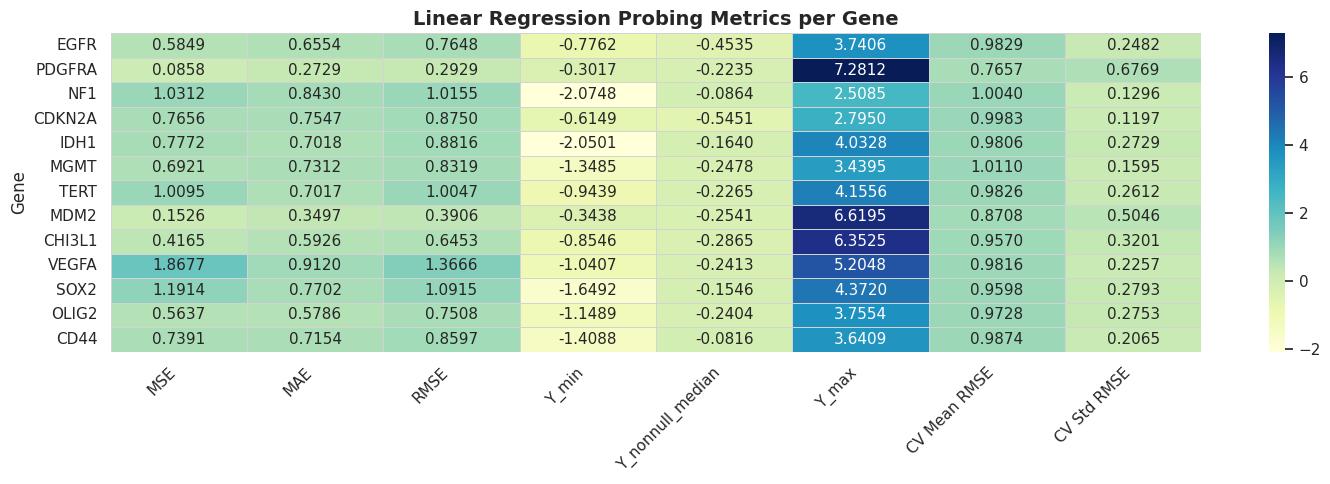

{'lp_wes':      Gene  Accuracy  ROC AUC  CV Mean ROC AUC  CV Std ROC AUC
 0    TP53    0.3636   0.3929           0.6410          0.1287
 1    EGFR    0.6364   0.6667           0.6996          0.1219
 2    PTEN    0.5455   0.5470           0.6259          0.2004
 3     NF1    0.7273   0.6491           0.5649          0.0795
 4  PIK3CA    0.7273   0.4250           0.3809          0.1514
 5  PIK3R1    0.9091   0.5000           0.4768          0.2417,
 'lp_bulk':       Gene     MSE     MAE    RMSE   Y_min  Y_nonnull_median   Y_max  \
 0     EGFR  0.5849  0.6554  0.7648 -0.7762           -0.4535  3.7406   
 1   PDGFRA  0.0858  0.2729  0.2929 -0.3017           -0.2235  7.2812   
 2      NF1  1.0312  0.8430  1.0155 -2.0748           -0.0864  2.5085   
 3   CDKN2A  0.7656  0.7547  0.8750 -0.6149           -0.5451  2.7950   
 4     IDH1  0.7772  0.7018  0.8816 -2.0501           -0.1640  4.0328   
 5     MGMT  0.6921  0.7312  0.8319 -1.3485           -0.2478  3.4395   
 6     TERT  1.0095  0.701

In [35]:
analyze_embeddings(snvs_indels, bRNA_TPM, batch_all, "new_joined_no_refinement", "./new_joined_no_refinement/", batch = clm_outputs[1])

### New_joined

In [36]:
jm = load_model(JoinedModule, 
                 "/home/sagemaker-user/gbm_hackathon/saved_models/new_joined.ckpt",
                "/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_joined.ckpt",
                device= "cpu")
constrative_outputs = jm.mme(X_dict)
tensor = concat_modality_embeddings(constrative_outputs)
clm_outputs = jm.clm.refinement_block(constrative_outputs, avail_mods)

{'net_type': 'mlp', 'device': device(type='cpu'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found

Model succesfully loaded on

Best Silouhette Score :0.2980741560459137


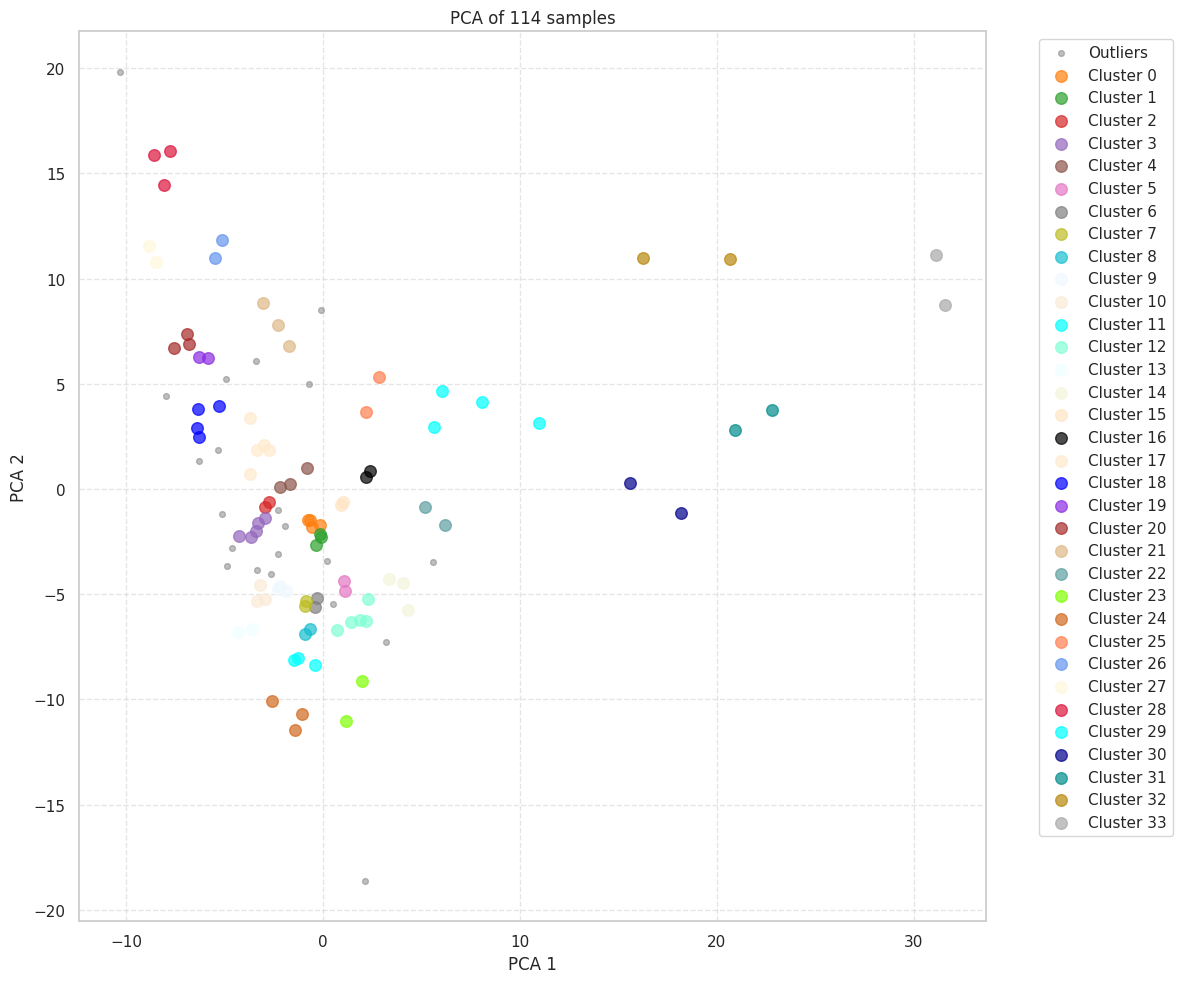

Best Silouhette Score :0.3713095188140869


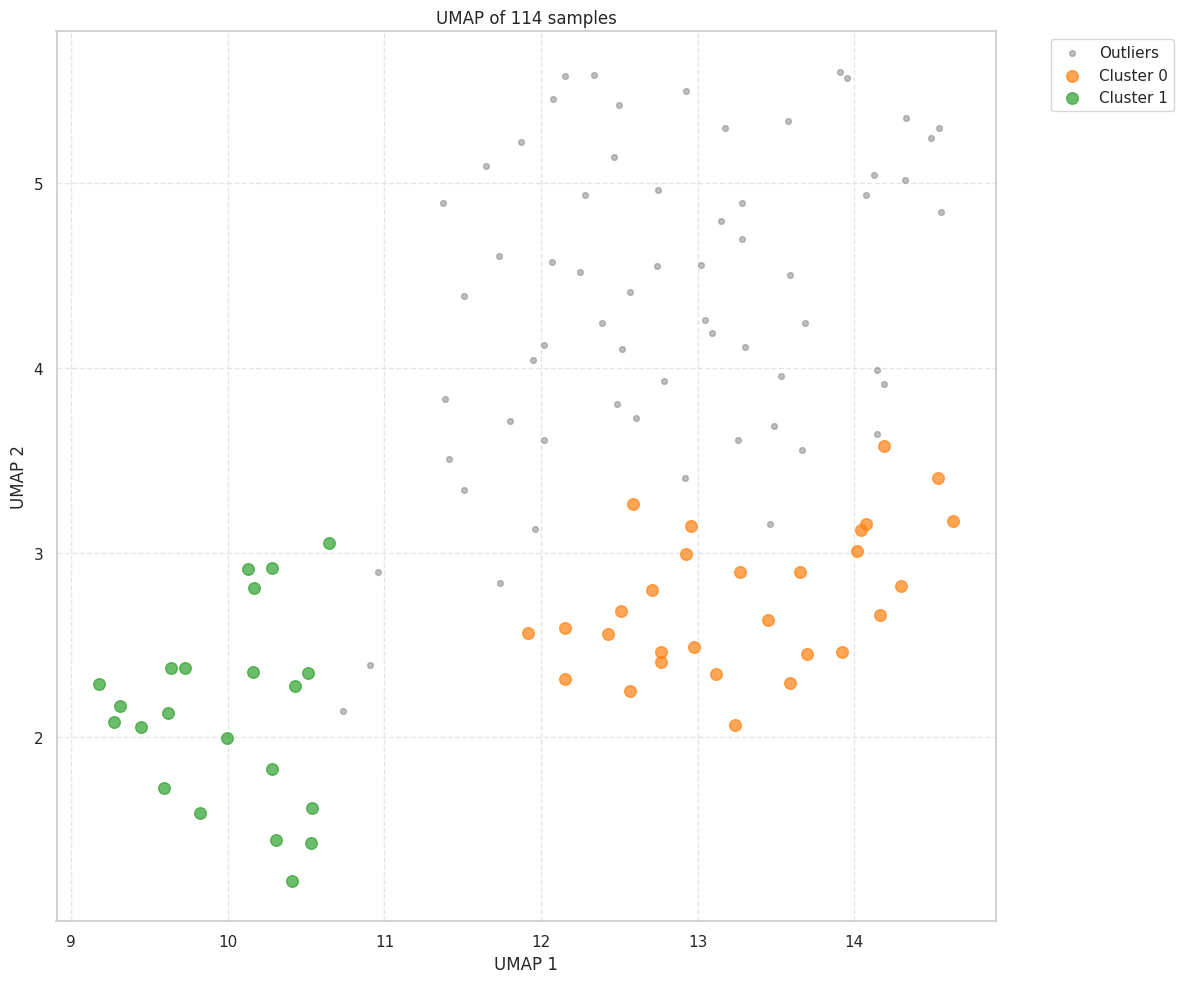

Accuracy: 0.5909090909090909
ROC AUC: 0.4464285714285715
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.79      0.71        14
           1       0.40      0.25      0.31         8

    accuracy                           0.59        22
   macro avg       0.52      0.52      0.51        22
weighted avg       0.56      0.59      0.56        22

Mean ROC AUC (CV): 0.6287074829931972
Accuracy: 0.6363636363636364
ROC AUC: 0.4666666666666666
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73        15
           1       0.43      0.43      0.43         7

    accuracy                           0.64        22
   macro avg       0.58      0.58      0.58        22
weighted avg       0.64      0.64      0.64        22

Mean ROC AUC (CV): 0.621470588235294
Accuracy: 0.6363636363636364
ROC AUC: 0.5982905982905983
Classification Report:
               precision    r

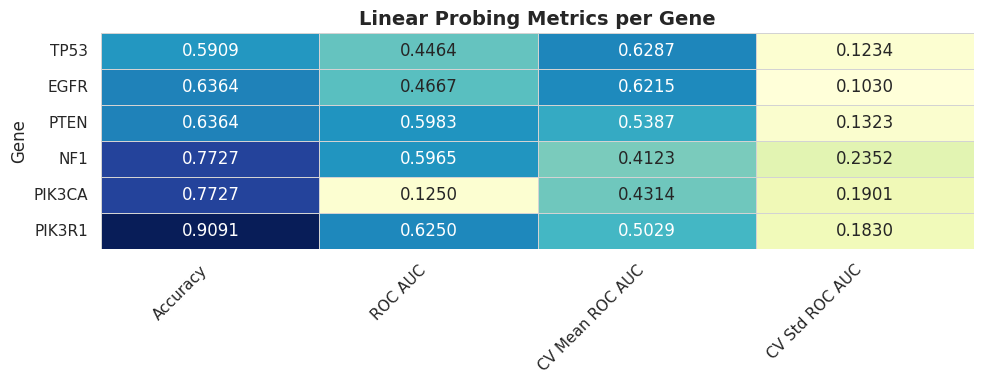

Mean Squared Error (MSE): 0.5849288008633626
Mean Absolute Error (MAE): 0.6554495200608274
RMSE Score: 0.764806381290953
Y_min: -0.7761717795112287, Y_max: 3.7406076994731627
Mean RMSE (CV): 0.9829129382198636
9th percentile -0.7761475580547708


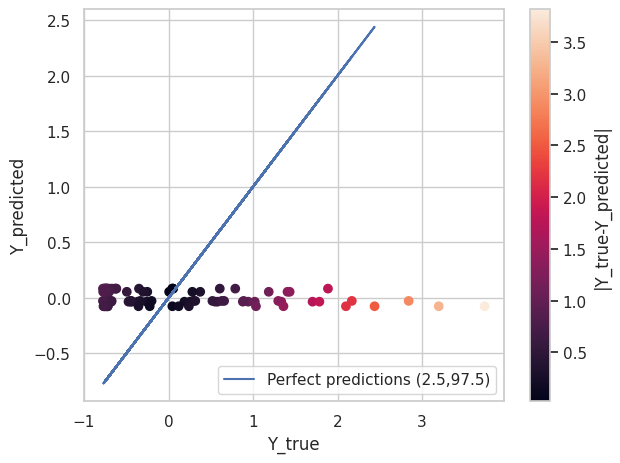

Mean Squared Error (MSE): 0.08579839529773702
Mean Absolute Error (MAE): 0.27290900039099864
RMSE Score: 0.2929136311231299
Y_min: -0.3017419966483975, Y_max: 7.281162278718516
Mean RMSE (CV): 0.765654424280652
9th percentile -0.30147383832265656


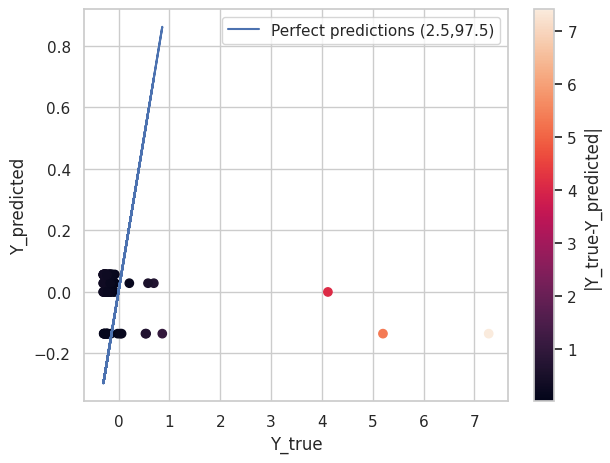

Mean Squared Error (MSE): 1.0311678906504749
Mean Absolute Error (MAE): 0.8430253300039371
RMSE Score: 1.015464371925709
Y_min: -2.0748497509996207, Y_max: 2.5085290479017854
Mean RMSE (CV): 1.0039706531414658
9th percentile -1.9468705923912122


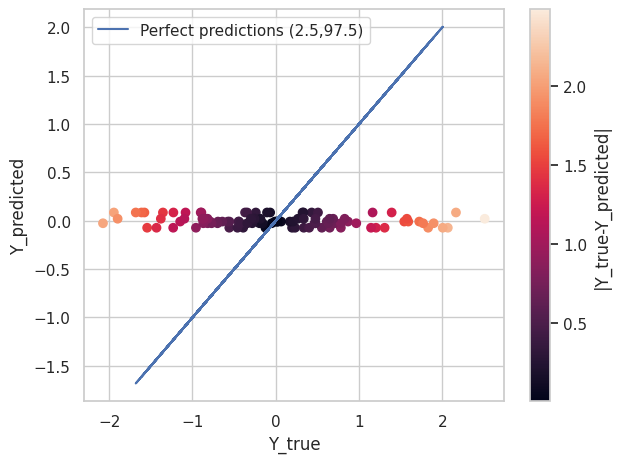

Mean Squared Error (MSE): 0.7655529310518899
Mean Absolute Error (MAE): 0.7547361745534579
RMSE Score: 0.8749588167747611
Y_min: -0.6148844930583284, Y_max: 2.7949966476216597
Mean RMSE (CV): 0.9982721734528794
9th percentile -0.6133712585363859


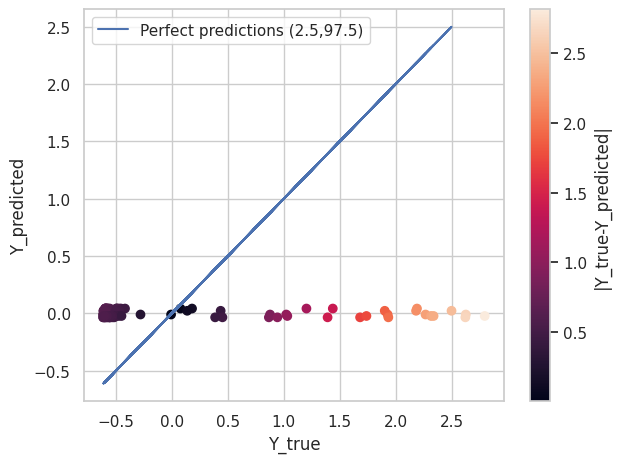

Mean Squared Error (MSE): 0.7772311718344819
Mean Absolute Error (MAE): 0.7018299225522849
RMSE Score: 0.8816071527809208
Y_min: -2.050127930977046, Y_max: 4.032821908282289
Mean RMSE (CV): 0.9806480268459492
9th percentile -1.785775640228863


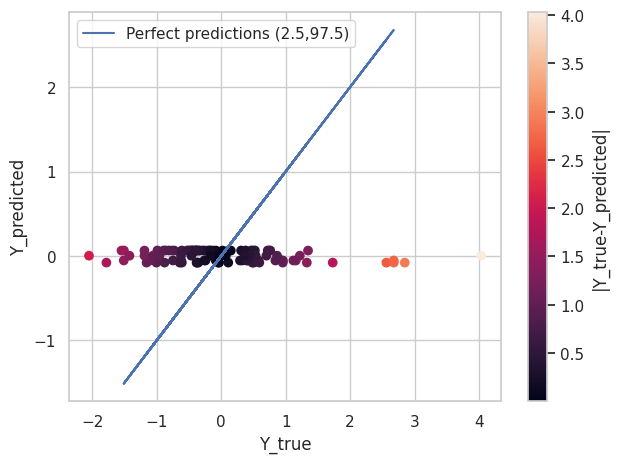

Mean Squared Error (MSE): 0.6920654505059426
Mean Absolute Error (MAE): 0.7312218906925478
RMSE Score: 0.831904712395562
Y_min: -1.3485242131873187, Y_max: 3.439450290420453
Mean RMSE (CV): 1.0110151412081028
9th percentile -1.3052585543893878


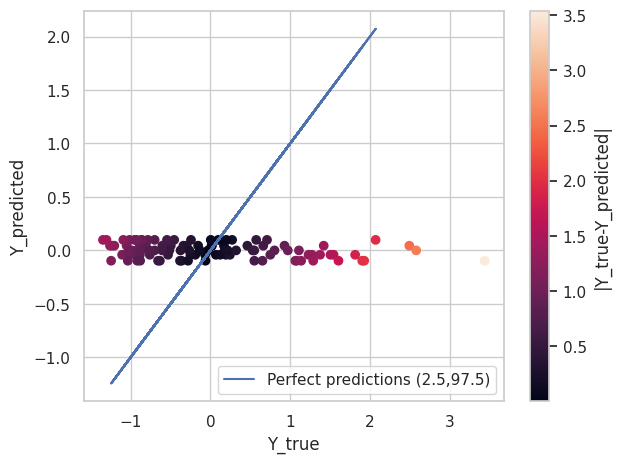

Mean Squared Error (MSE): 1.0094605330668212
Mean Absolute Error (MAE): 0.7017108639072889
RMSE Score: 1.004719131432671
Y_min: -0.9438632436261545, Y_max: 4.155649606554423
Mean RMSE (CV): 0.9826486123770011
9th percentile -0.9438632436261545


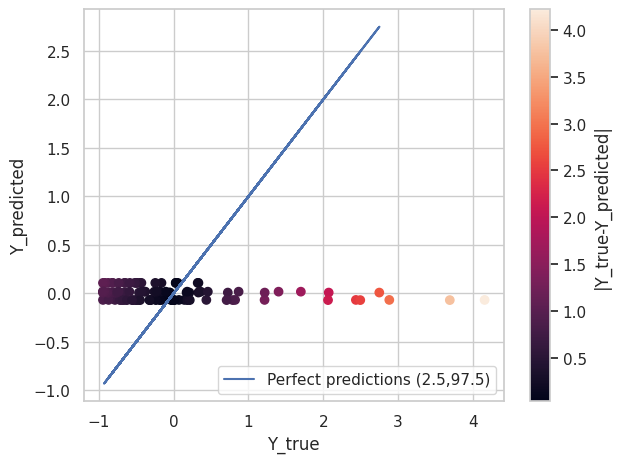

Mean Squared Error (MSE): 0.15258193526217992
Mean Absolute Error (MAE): 0.34966730310522204
RMSE Score: 0.3906173770612105
Y_min: -0.3437568256133891, Y_max: 6.619521078607543
Mean RMSE (CV): 0.8708284267687437
9th percentile -0.3296203036934892


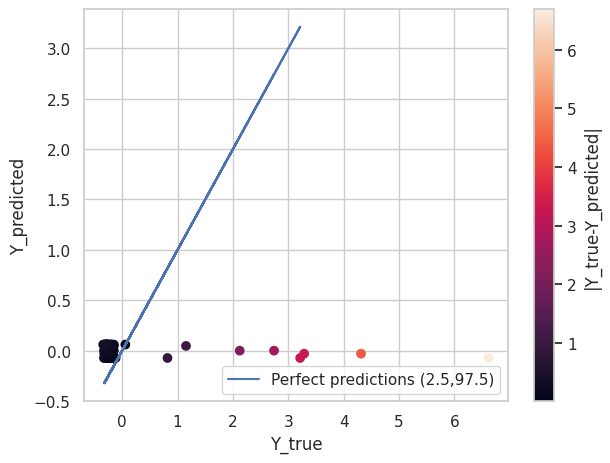

Mean Squared Error (MSE): 0.4164746046673043
Mean Absolute Error (MAE): 0.5925833602049839
RMSE Score: 0.6453484366350509
Y_min: -0.8546475030574292, Y_max: 6.352482935852151
Mean RMSE (CV): 0.9569836536651364
9th percentile -0.8515743231820007


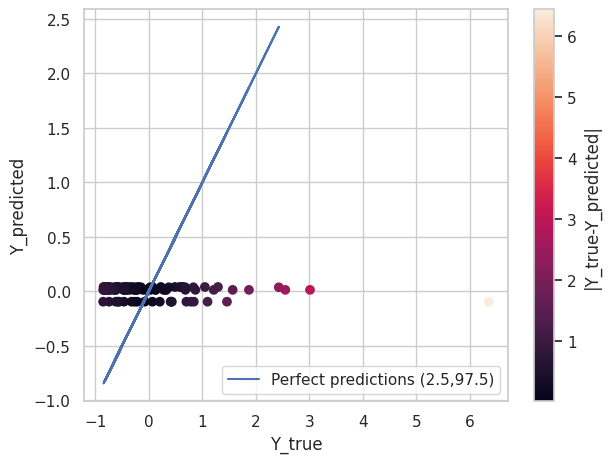

Mean Squared Error (MSE): 1.8676571227427325
Mean Absolute Error (MAE): 0.911973417191684
RMSE Score: 1.366622523867777
Y_min: -1.0406770201116537, Y_max: 5.204775754553968
Mean RMSE (CV): 0.9816083047052127
9th percentile -1.0375753757661121


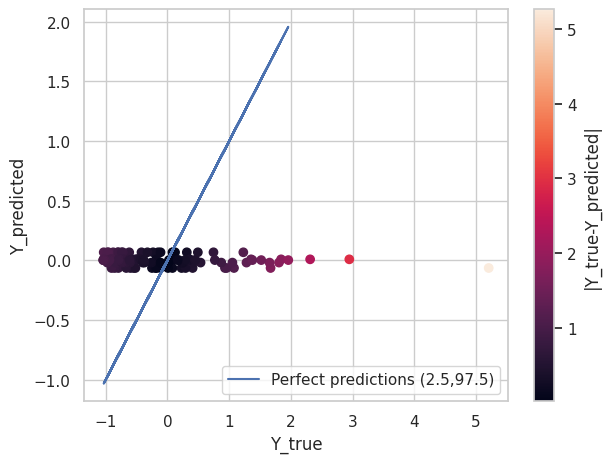

Mean Squared Error (MSE): 1.1913532341646884
Mean Absolute Error (MAE): 0.770155153202109
RMSE Score: 1.0914912890924455
Y_min: -1.6491985515099434, Y_max: 4.3719944781247335
Mean RMSE (CV): 0.9597806266348534
9th percentile -1.6428461610821528


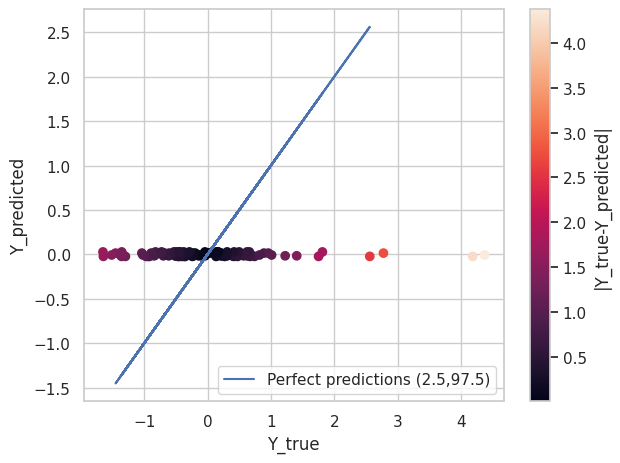

Mean Squared Error (MSE): 0.5637386395109937
Mean Absolute Error (MAE): 0.578558567569321
RMSE Score: 0.7508253055877869
Y_min: -1.1489154688789, Y_max: 3.7554242093284333
Mean RMSE (CV): 0.9727794554571674
9th percentile -1.1468838665895458


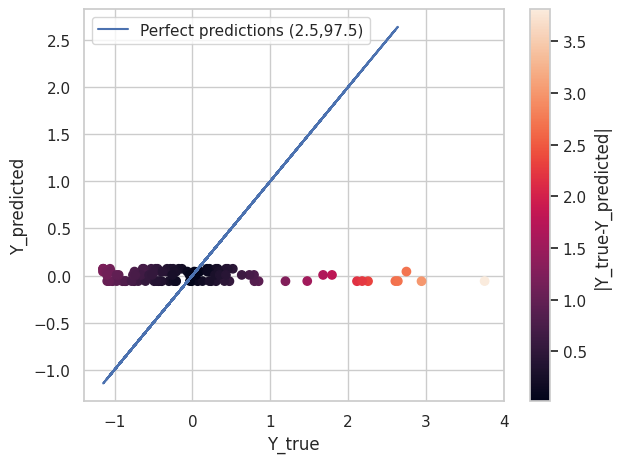

Mean Squared Error (MSE): 0.7391311692959457
Mean Absolute Error (MAE): 0.7153921240605595
RMSE Score: 0.8597273807992541
Y_min: -1.4088430206480322, Y_max: 3.640884875730961
Mean RMSE (CV): 0.9874270010307681
9th percentile -1.3935864958347566


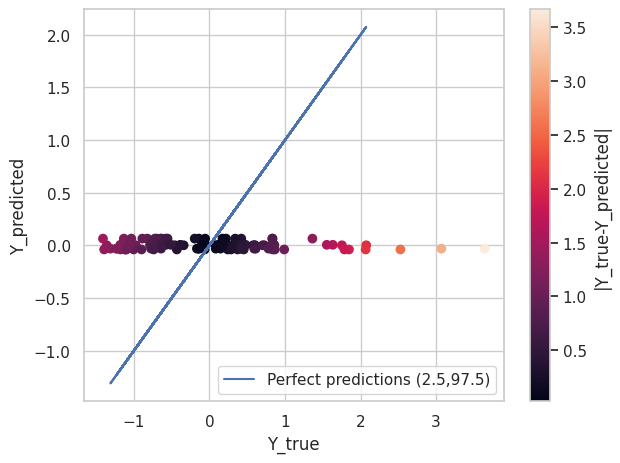

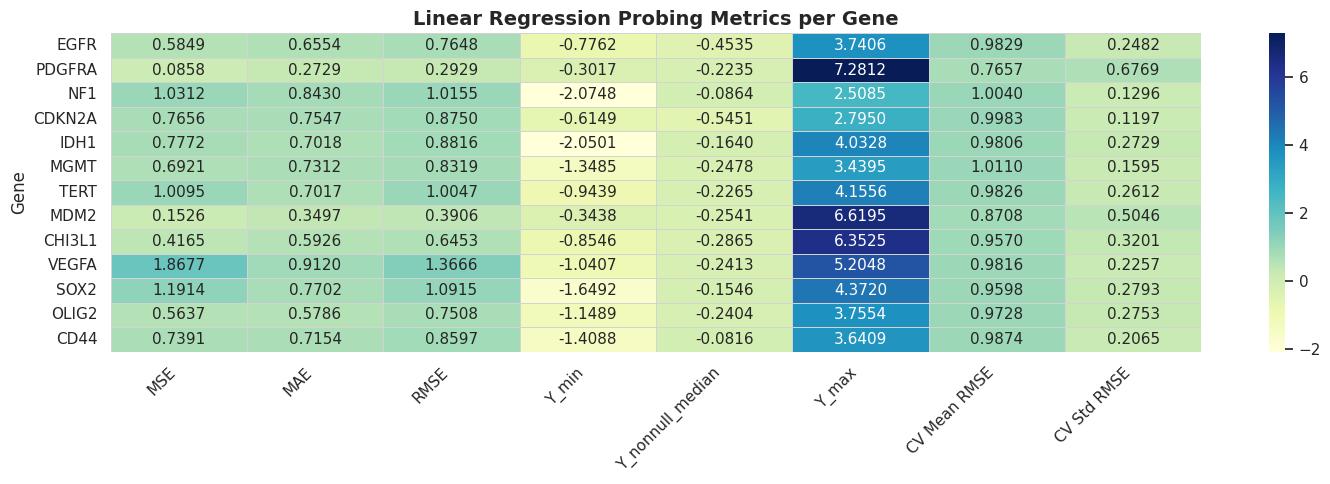

{'lp_wes':      Gene  Accuracy  ROC AUC  CV Mean ROC AUC  CV Std ROC AUC
 0    TP53    0.5909   0.4464           0.6287          0.1234
 1    EGFR    0.6364   0.4667           0.6215          0.1030
 2    PTEN    0.6364   0.5983           0.5387          0.1323
 3     NF1    0.7727   0.5965           0.4123          0.2352
 4  PIK3CA    0.7727   0.1250           0.4314          0.1901
 5  PIK3R1    0.9091   0.6250           0.5029          0.1830,
 'lp_bulk':       Gene     MSE     MAE    RMSE   Y_min  Y_nonnull_median   Y_max  \
 0     EGFR  0.5849  0.6554  0.7648 -0.7762           -0.4535  3.7406   
 1   PDGFRA  0.0858  0.2729  0.2929 -0.3017           -0.2235  7.2812   
 2      NF1  1.0312  0.8430  1.0155 -2.0748           -0.0864  2.5085   
 3   CDKN2A  0.7656  0.7547  0.8750 -0.6149           -0.5451  2.7950   
 4     IDH1  0.7772  0.7018  0.8816 -2.0501           -0.1640  4.0328   
 5     MGMT  0.6921  0.7312  0.8319 -1.3485           -0.2478  3.4395   
 6     TERT  1.0095  0.701

In [37]:
analyze_embeddings(snvs_indels, bRNA_TPM, batch_all, "new_joined", "./new_joined/", batch = clm_outputs)

### Naive

In [38]:
from gbmhackathon.utils.model_saving import CPU_Unpickler

with open("../experiments/early_fusion_embeddings/naive.pkl", 'rb') as f:
    naive_ealy = CPU_Unpickler(f).load()

In [39]:
naive_ealy

{'hne': tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [-0.2171,  0.1554,  0.1590,  ...,  0.2429,  0.1488, -0.0353],
         [-0.3007, -0.2039, -0.3413,  ...,  0.1311,  0.1175, -0.0291],
         ...,
         [ 0.0874, -0.1747,  0.0190,  ..., -0.1025,  0.1095, -0.0375],
         [ 0.0703, -0.2376,  0.0129,  ..., -0.1205,  0.2786,  0.0950],
         [-0.1102, -0.1267, -0.2843,  ..., -0.1372, -0.0607,  0.0096]]),
 'spatial': tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [-0.1097, -0.0281,  0.2079,  ..., -0.2415, -0.1683, -0.1062],
         [-0.1014, -0.0240,  0.1923,  ..., -0.2473, -0.1743, -0.0996],
         ...,
         [-0.0173, -0.0311,  0.1502,  ..., -0.2646, -0.1770, -0.0938],
         [-0.0606, -0.0358,  0.1831,  ..., -0.2555, -0.1785, -0.0895],
         [-0.0891, -0.0292,  0.1796,  ..., -0.2247, -0.1573, -0.1201]]),
 'clinical': tensor([[-0.4366, -0.4253, -0.2274,  ..., -0.4151, -0.4482, -0.4312],
         [-0.50

Best Silouhette Score :0.3804437816143036


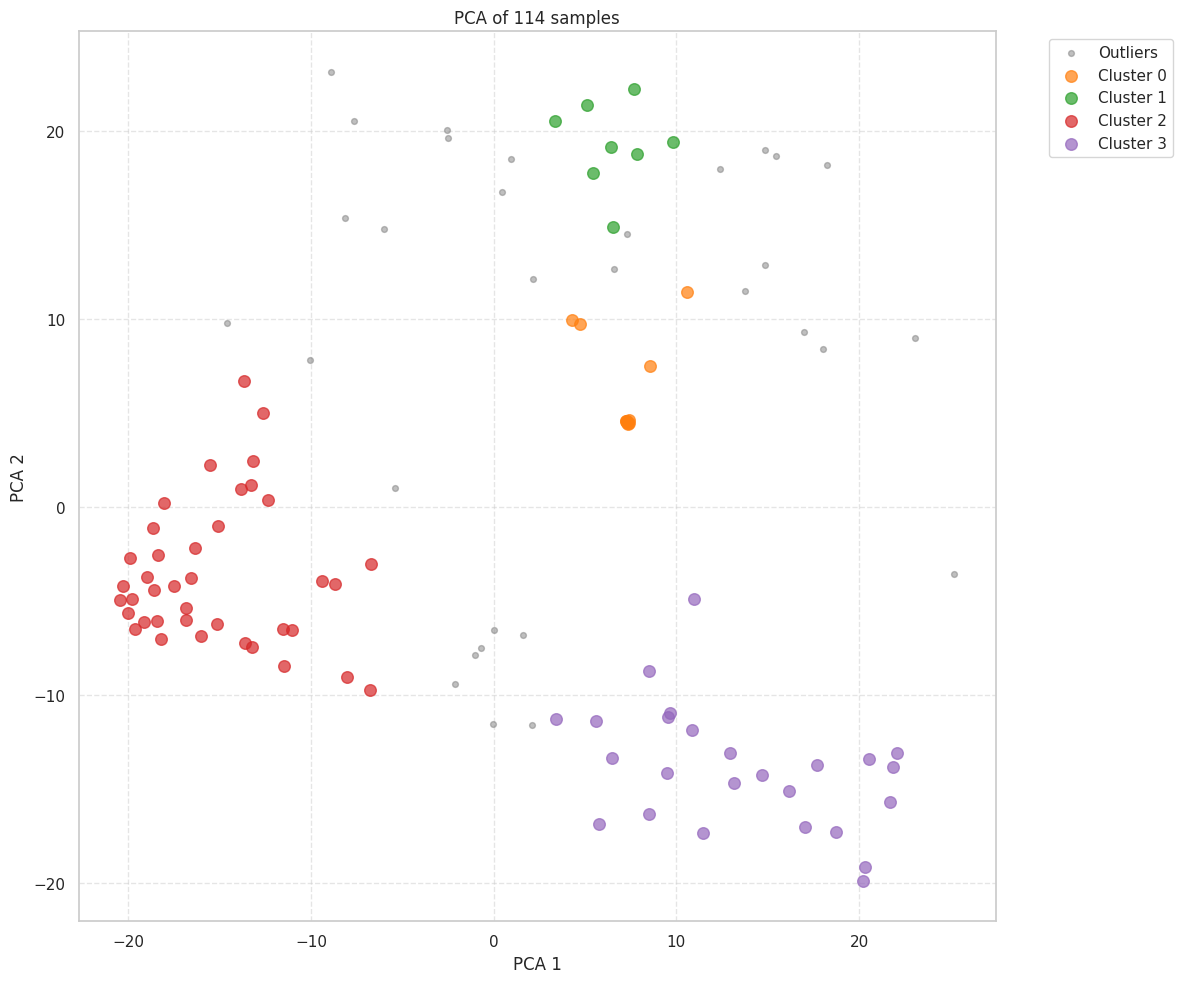

Best Silouhette Score :0.5717183351516724


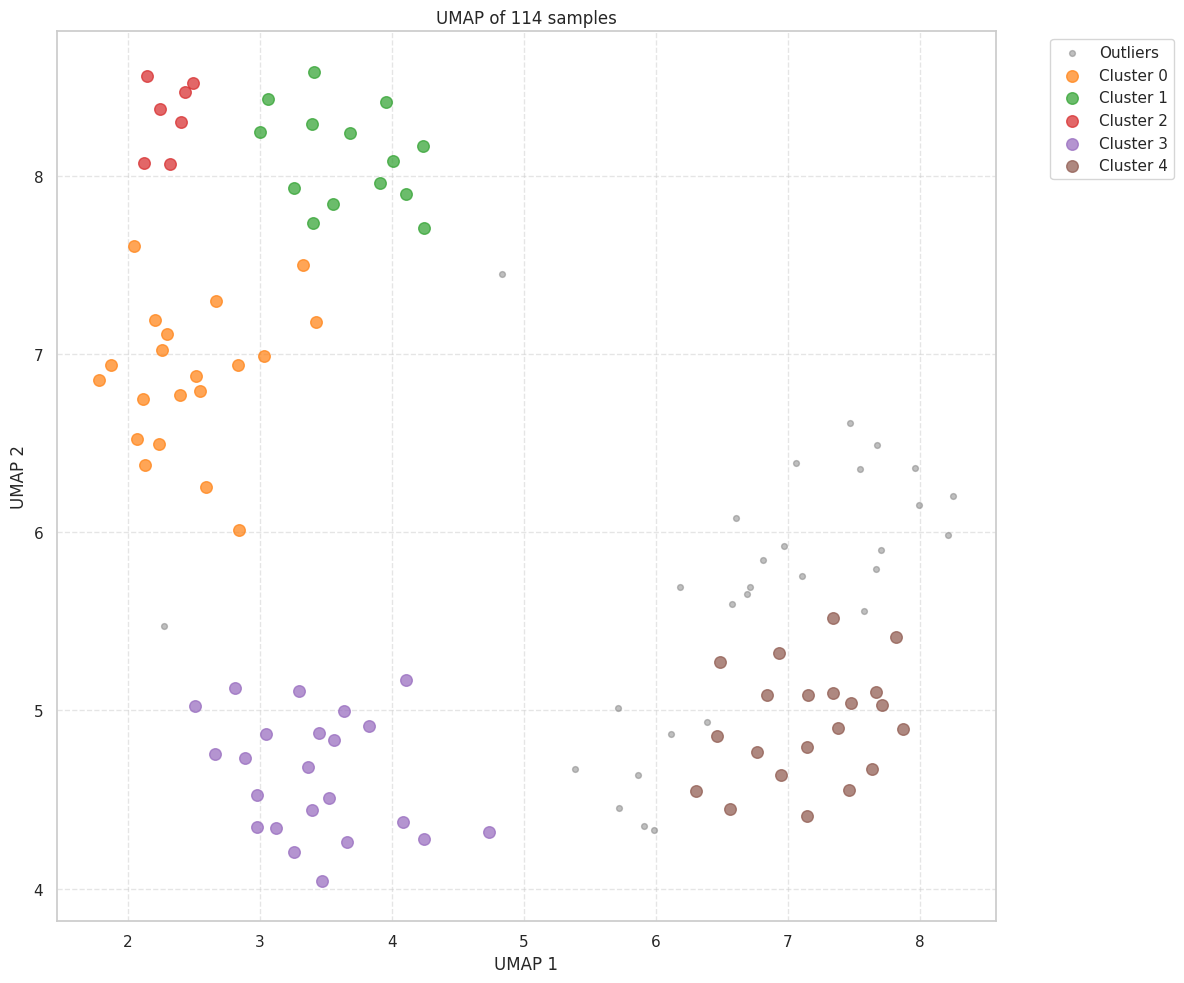

Accuracy: 0.6818181818181818
ROC AUC: 0.6964285714285714
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.93      0.79        14
           1       0.67      0.25      0.36         8

    accuracy                           0.68        22
   macro avg       0.68      0.59      0.58        22
weighted avg       0.68      0.68      0.63        22

Mean ROC AUC (CV): 0.5912925170068026
Accuracy: 0.5909090909090909
ROC AUC: 0.22857142857142856
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.87      0.74        15
           1       0.00      0.00      0.00         7

    accuracy                           0.59        22
   macro avg       0.33      0.43      0.37        22
weighted avg       0.44      0.59      0.51        22

Mean ROC AUC (CV): 0.4325
Accuracy: 0.5454545454545454
ROC AUC: 0.5641025641025641
Classification Report:
               precision    recall  f1-

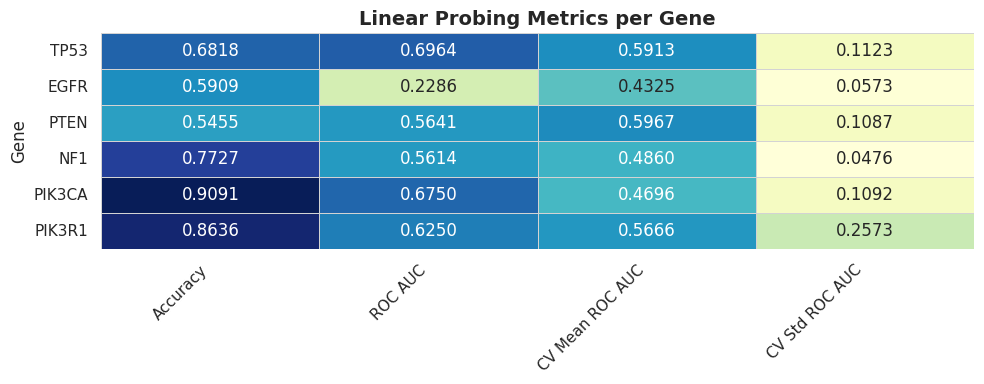

Mean Squared Error (MSE): 0.5849288008633626
Mean Absolute Error (MAE): 0.6554495200608274
RMSE Score: 0.764806381290953
Y_min: -0.7761717795112287, Y_max: 3.7406076994731627
Mean RMSE (CV): 0.9829129382198636
9th percentile -0.7761475580547708


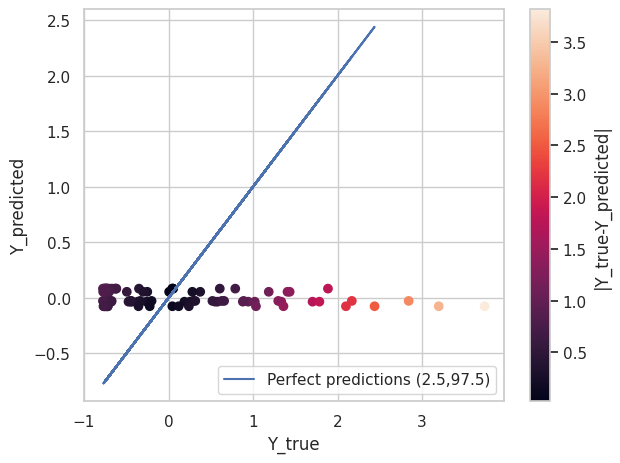

Mean Squared Error (MSE): 0.08579839529773702
Mean Absolute Error (MAE): 0.27290900039099864
RMSE Score: 0.2929136311231299
Y_min: -0.3017419966483975, Y_max: 7.281162278718516
Mean RMSE (CV): 0.765654424280652
9th percentile -0.30147383832265656


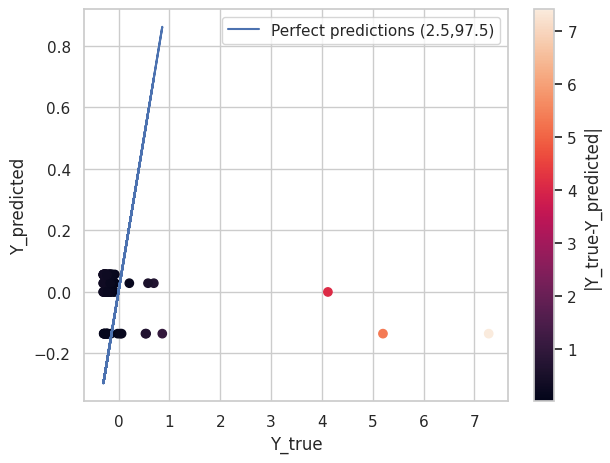

Mean Squared Error (MSE): 1.0311678906504749
Mean Absolute Error (MAE): 0.8430253300039371
RMSE Score: 1.015464371925709
Y_min: -2.0748497509996207, Y_max: 2.5085290479017854
Mean RMSE (CV): 1.0039706531414658
9th percentile -1.9468705923912122


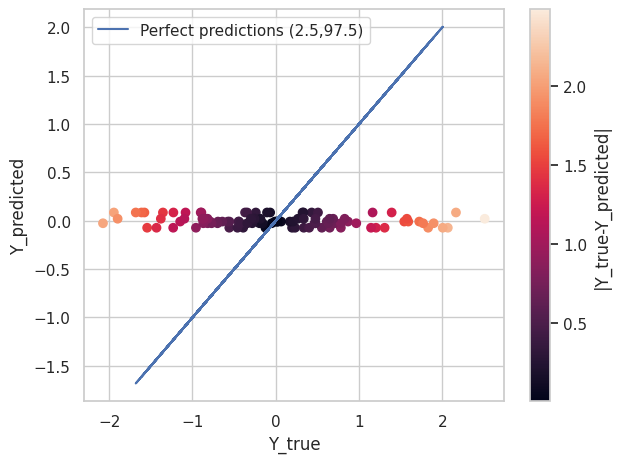

Mean Squared Error (MSE): 0.7655529310518899
Mean Absolute Error (MAE): 0.7547361745534579
RMSE Score: 0.8749588167747611
Y_min: -0.6148844930583284, Y_max: 2.7949966476216597
Mean RMSE (CV): 0.9982721734528794
9th percentile -0.6133712585363859


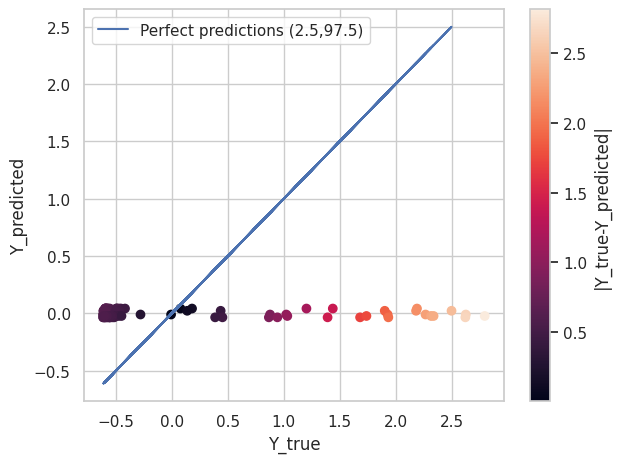

Mean Squared Error (MSE): 0.7772311718344819
Mean Absolute Error (MAE): 0.7018299225522849
RMSE Score: 0.8816071527809208
Y_min: -2.050127930977046, Y_max: 4.032821908282289
Mean RMSE (CV): 0.9806480268459492
9th percentile -1.785775640228863


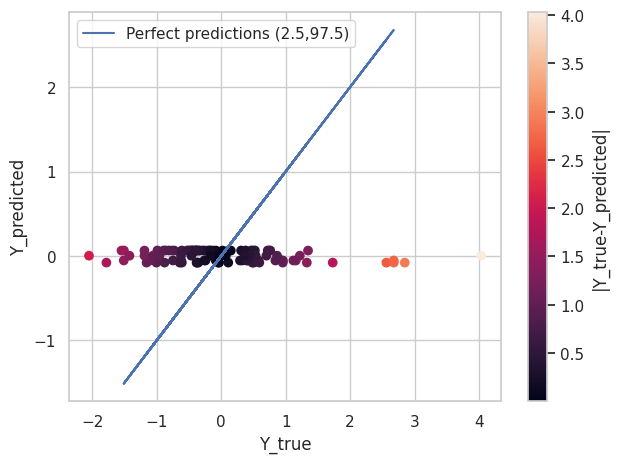

Mean Squared Error (MSE): 0.6920654505059426
Mean Absolute Error (MAE): 0.7312218906925478
RMSE Score: 0.831904712395562
Y_min: -1.3485242131873187, Y_max: 3.439450290420453
Mean RMSE (CV): 1.0110151412081028
9th percentile -1.3052585543893878


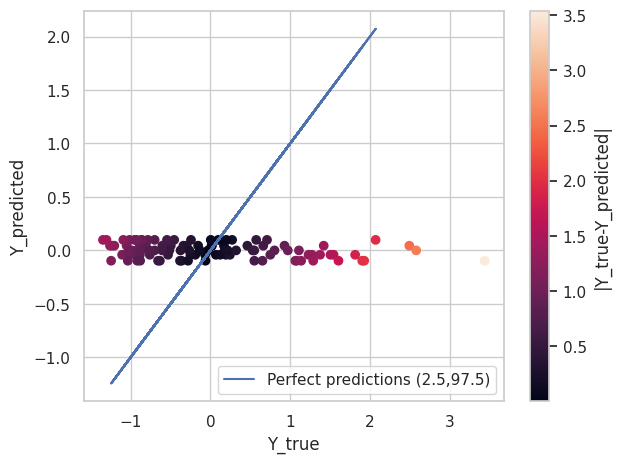

Mean Squared Error (MSE): 1.0094605330668212
Mean Absolute Error (MAE): 0.7017108639072889
RMSE Score: 1.004719131432671
Y_min: -0.9438632436261545, Y_max: 4.155649606554423
Mean RMSE (CV): 0.9826486123770011
9th percentile -0.9438632436261545


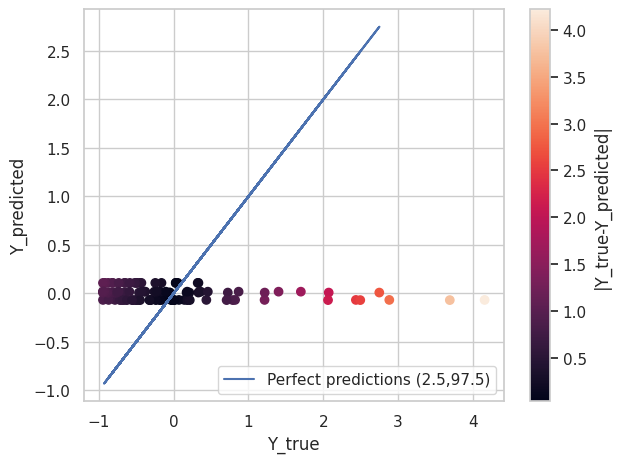

Mean Squared Error (MSE): 0.15258193526217992
Mean Absolute Error (MAE): 0.34966730310522204
RMSE Score: 0.3906173770612105
Y_min: -0.3437568256133891, Y_max: 6.619521078607543
Mean RMSE (CV): 0.8708284267687437
9th percentile -0.3296203036934892


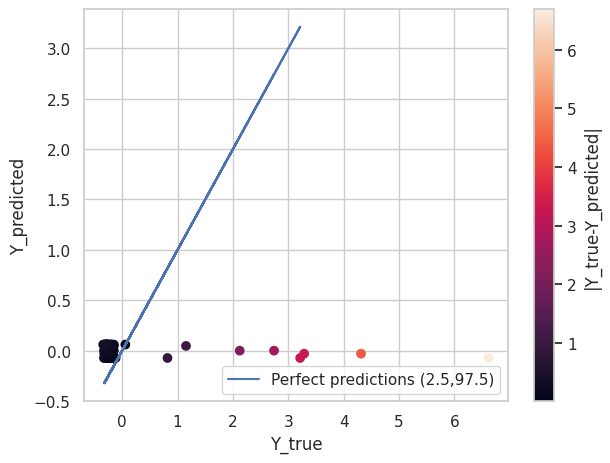

Mean Squared Error (MSE): 0.4164746046673043
Mean Absolute Error (MAE): 0.5925833602049839
RMSE Score: 0.6453484366350509
Y_min: -0.8546475030574292, Y_max: 6.352482935852151
Mean RMSE (CV): 0.9569836536651364
9th percentile -0.8515743231820007


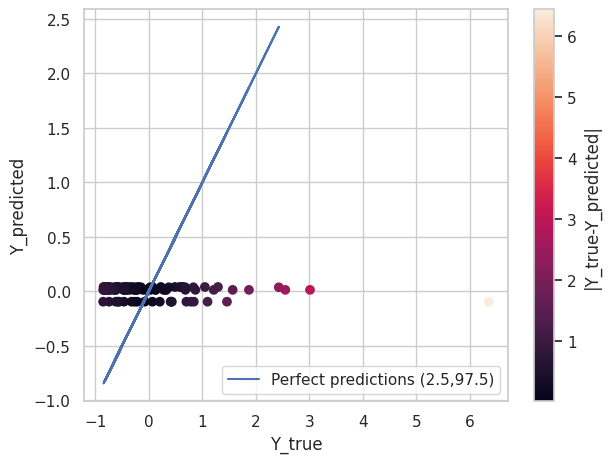

Mean Squared Error (MSE): 1.8676571227427325
Mean Absolute Error (MAE): 0.911973417191684
RMSE Score: 1.366622523867777
Y_min: -1.0406770201116537, Y_max: 5.204775754553968
Mean RMSE (CV): 0.9816083047052127
9th percentile -1.0375753757661121


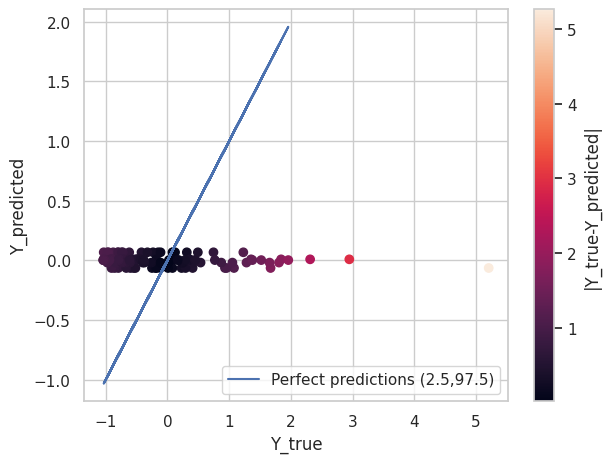

Mean Squared Error (MSE): 1.1913532341646884
Mean Absolute Error (MAE): 0.770155153202109
RMSE Score: 1.0914912890924455
Y_min: -1.6491985515099434, Y_max: 4.3719944781247335
Mean RMSE (CV): 0.9597806266348534
9th percentile -1.6428461610821528


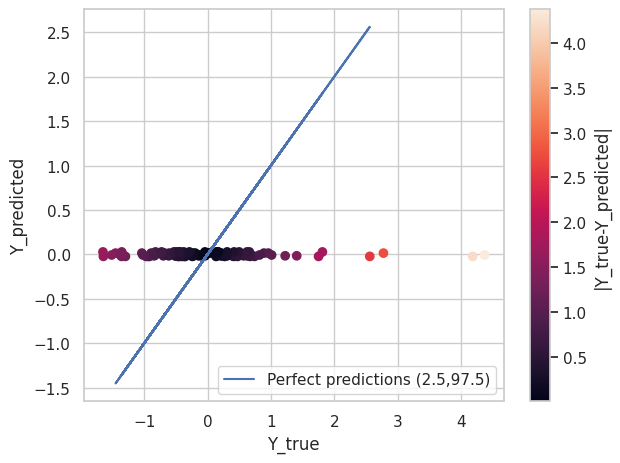

Mean Squared Error (MSE): 0.5637386395109937
Mean Absolute Error (MAE): 0.578558567569321
RMSE Score: 0.7508253055877869
Y_min: -1.1489154688789, Y_max: 3.7554242093284333
Mean RMSE (CV): 0.9727794554571674
9th percentile -1.1468838665895458


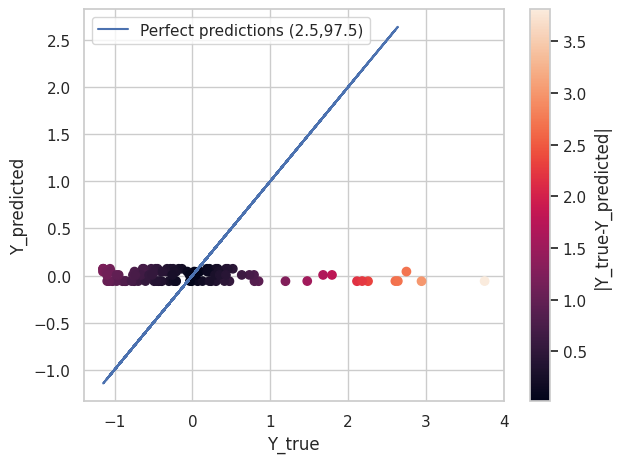

Mean Squared Error (MSE): 0.7391311692959457
Mean Absolute Error (MAE): 0.7153921240605595
RMSE Score: 0.8597273807992541
Y_min: -1.4088430206480322, Y_max: 3.640884875730961
Mean RMSE (CV): 0.9874270010307681
9th percentile -1.3935864958347566


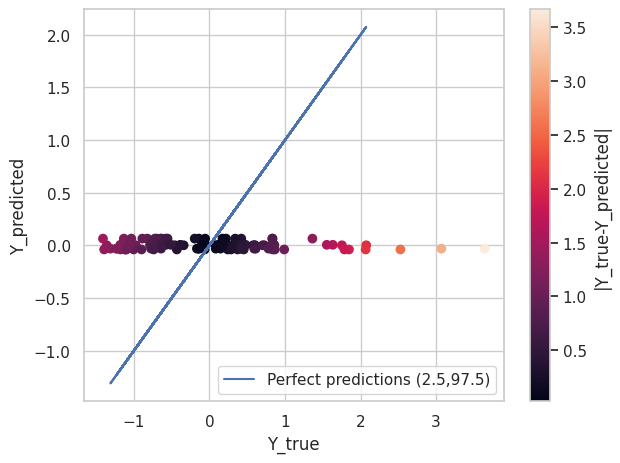

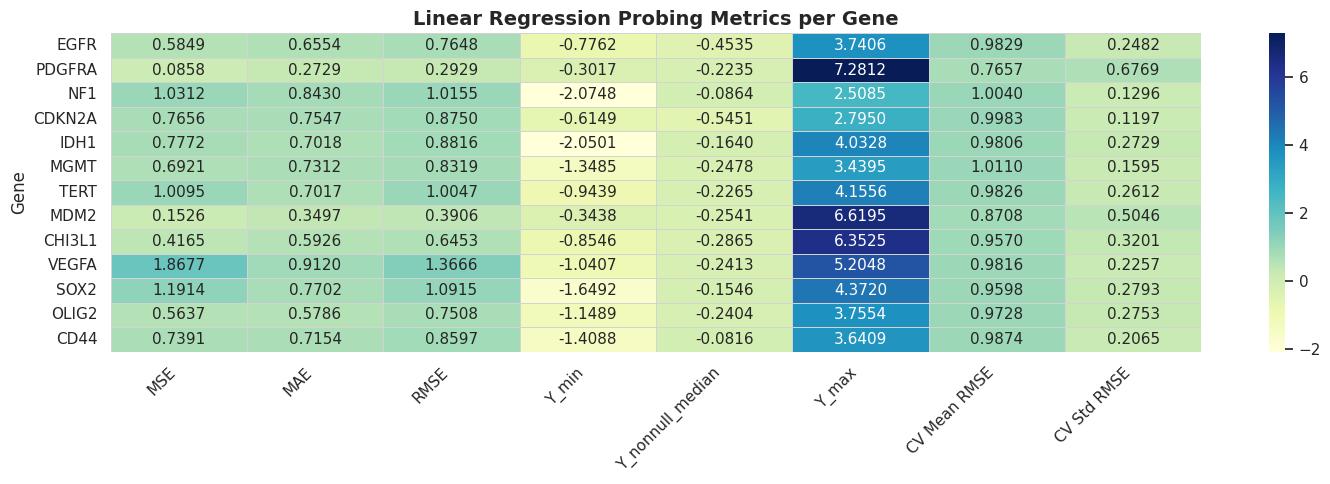

In [ ]:
analyze_embeddings(snvs_indels, bRNA_TPM, batch_all, "naive", "./naive/", emb_path= "../experiments/early_fusion_embeddings/naive.pkl")

### pca early

In [ ]:
analyze_embeddings(snvs_indels, bRNA_TPM, batch_all, "pca", "./pca/", emb_path= "../experiments/early_fusion_embeddings/pca.pkl")